In [5]:
import pandas as pd
import numpy as np
import seaborn as sns
from tabulate import tabulate
import matplotlib.pyplot as plt
pd.set_option('display.max_columns', None)

In [6]:
try:
    df_original = pd.read_csv('Kids_guds_2017_09_10.csv',
                             encoding='windows-1251', 
                             sep=';')         

    print("Файл загружен с кодировкой windows-1251")
    print(f"Колонки: {list(df_original.columns)}")

except Exception as e:
    print(f"Ошибка: {e}")

Файл загружен с кодировкой windows-1251
Колонки: ['Дата', 'ДатаДоставки', 'НомерЗаказаНаСайте', 'НовыйСтатус', 'СуммаЗаказаНаСайте', 'СуммаДокумента', 'МетодДоставки', 'ФормаОплаты', 'Регион', 'Группа2', 'Группа3', 'Группа4', 'Тип', 'Номенклатура', 'ТипТовара', 'Отменено', 'ПричинаОтмены', 'Количество', 'Цена', 'СуммаСтроки', 'ЦенаЗакупки', 'МесяцДатыЗаказа', 'ГодДатыЗаказа', 'ПВЗ_код', 'Статус', 'Гео', 'Маржа', 'СуммаУслуг', 'СуммаДоставки', 'НомерСтроки', 'КоличествоПроданоКлиенту', 'ДатаЗаказаНаСайте', 'Телефон_new', 'ЭлектроннаяПочта_new', 'Клиент', 'ID_SKU', 'ГородМагазина', 'МагазинЗаказа']


In [7]:
df = df_original

In [8]:
df.shape[0]

876075

In [54]:
df.head()

,Дата,ДатаДоставки,НомерЗаказаНаСайте,НовыйСтатус,СуммаЗаказаНаСайте,СуммаДокумента,МетодДоставки,ФормаОплаты,Регион,Группа2,Группа3,Группа4,Тип,Номенклатура,ТипТовара,Отменено,ПричинаОтмены,Количество,Цена,СуммаСтроки,ЦенаЗакупки,МесяцДатыЗаказа,ГодДатыЗаказа,ПВЗ_код,Статус,Гео,Маржа,СуммаУслуг,СуммаДоставки,НомерСтроки,КоличествоПроданоКлиенту,ДатаЗаказаНаСайте,Телефон_new,ЭлектроннаяПочта_new,Клиент,ID_SKU,ГородМагазина,МагазинЗаказа
0,01.09.2017 11:34,08.09.2017 0:00,5412440_TR,Отменен,2614.0,150.0,Курьерская,Наличная,Москва,NaN,NaN,NaN,ИНОЕ,Доставка,NaN,Нет,NaN,1,150.0,150.0,NaN,9,2 017,NaN,Отменен,Москва,NaN,150.0,150.0,1,1,31.08.2017 0:00,55574851-49485350505178,103117_gu12@mail.ru,Валентина,ID10022107250,0,NaN
1,01.09.2017 11:34,08.09.2017 0:00,5412440_TR,Отменен,2614.0,150.0,Курьерская,Наличная,Москва,ИГРУШКИ,ИГРУШКИ ДЛЯ ДЕВОЧЕК,наборы игровые,ИГРУШКИ,"PLAYSKOOL, ИГРУШКА Музыкальный замок Пони",МГТ,Да,2.1 Не устроила дата доставки,1,1382.0,1382.0,1974.00,9,2 017,NaN,Отменен,Москва,-592.00,150.0,150.0,2,1,31.08.2017 0:00,55574851-49485350505178,103117_gu12@mail.ru,Валентина,IDL00021467250,0,NaN
2,01.09.2017 11:34,08.09.2017 0:00,5412440_TR,Отменен,2614.0,150.0,Курьерская,Наличная,Москва,ИГРУШКИ,ИГРУШКИ ДЛЯ ДЕВОЧЕК,наборы игровые,ИГРУШКИ,"MY LITTLE PONY, НАБОР игровой Поезд Дружбы",МГТ,Да,2.1 Не устроила дата доставки,1,843.0,843.0,1685.20,9,2 017,NaN,Отменен,Москва,-842.20,150.0,150.0,1,1,31.08.2017 0:00,55574851-49485350505178,103117_gu12@mail.ru,Валентина,IDL00036071149,0,NaN
3,01.09.2017 11:34,08.09.2017 0:00,5412440_TR,Отменен,2614.0,150.0,Курьерская,Наличная,Москва,ИГРУШКИ,ИГРУШКИ ДЛЯ РАЗВИТИЯ МАЛЫШЕЙ,прочие игрушки для развития,ИГРУШКИ,"УМКА , ЧАСЫ Фиксики, с проекцией",МГТ,Да,2.1 Не устроила дата доставки,1,239.0,239.0,154.98,9,2 017,NaN,Отменен,Москва,84.02,150.0,150.0,3,1,31.08.2017 0:00,55574851-49485350505178,103117_gu12@mail.ru,Валентина,IDL00038944553,0,NaN
4,01.09.2017 0:05,11.09.2017 0:00,5412441_TR,Возврат из ПВЗ,4563.0,4563.0,Магазины,Безналичная,Санкт-Петербург,NaN,NaN,NaN,ИНОЕ,Доставка,NaN,Нет,NaN,1,99.0,99.0,NaN,9,2 017,901000646,Возврат,Регионы,NaN,99.0,99.0,1,1,31.08.2017 0:00,55575049-55525257485770,106117_ju17@mail.ru,Гость,ID10022107250,0,NaN


In [9]:
# самые частые номера
df['Телефон_new'].value_counts().head(10)


Телефон_new
0                          2259
55575053-51514849554879     292
55574954-57485351535070     290
55575348-48565551534975     259
55574954-54555249514877     255
55574954-50494954545575     255
55575655-50505253555077     253
55574857-56565349525677     239
55574951-54554848555476     234
55574856-49505152484873     232
Name: count, dtype: int64

In [10]:
# Удалить строки где Телефон_new = 0
df = df[df['Телефон_new'] != '0']
df['Телефон_new'].value_counts().head(10)

Телефон_new
55575053-51514849554879    292
55574954-57485351535070    290
55575348-48565551534975    259
55574954-50494954545575    255
55574954-54555249514877    255
55575655-50505253555077    253
55574857-56565349525677    239
55574951-54554848555476    234
55574856-49505152484873    232
55574949-49545651525076    226
Name: count, dtype: int64

In [11]:
top_phones = df.groupby('Телефон_new').agg(
    количество_заказов=('НомерЗаказаНаСайте', 'nunique')
).sort_values('количество_заказов', ascending=False).head(10)

print("Топ 10 телефонов по количеству заказов:")
print(top_phones)

Топ 10 телефонов по количеству заказов:
                         количество_заказов
Телефон_new                                
55574949-49545651525076                  60
55574956-56575453545378                  58
55575054-53555154495074                  52
55574856-49505152484873                  46
55575054-50505252535072                  41
55575054-49505057545771                  32
55575054-57494849545177                  32
55574851-48484953515776                  32
55574957-55575356514873                  30
55575655-50505253555077                  28


In [ ]:
df[df['Телефон_new'] == '55574949-49545651525076'] #все корректно по числу заказов

In [27]:
# Посмотрим детали по самому активному "клиенту"
top_phone = '55574949-49545651525076'
top_client = df[df['Телефон_new'] == top_phone]

print(f"Телефон: {top_phone}")
print(f"Всего записей: {len(top_client)}")
print(f"Уникальных заказов: {top_client['НомерЗаказаНаСайте'].nunique()}")
print(f"Уникальных товаров: {top_client['ID_SKU'].nunique()}")
print(f"\nEmail'ы этого 'клиента':")
print(top_client['ЭлектроннаяПочта_new'].value_counts().head())

Телефон: 55574949-49545651525076
Всего записей: 226
Уникальных заказов: 60
Уникальных товаров: 158

Email'ы этого 'клиента':
ЭлектроннаяПочта_new
97117_au24@yandex.ru    226
Name: count, dtype: int64


In [15]:
df['Телефон_new'].value_counts().head(10)

Телефон_new
0                          2259
55575053-51514849554879     292
55574954-57485351535070     290
55575348-48565551534975     259
55574954-54555249514877     255
55574954-50494954545575     255
55575655-50505253555077     253
55574857-56565349525677     239
55574951-54554848555476     234
55574856-49505152484873     232
Name: count, dtype: int64

In [27]:
#наименования столбцов таблицы
cols = df.columns
for i in range(len(cols)):
  print(cols[i])

Дата
ДатаДоставки
НомерЗаказаНаСайте
НовыйСтатус
СуммаЗаказаНаСайте
СуммаДокумента
МетодДоставки
ФормаОплаты
Регион
Группа2
Группа3
Группа4
Тип
Номенклатура
ТипТовара
Отменено
ПричинаОтмены
Количество
Цена
СуммаСтроки
ЦенаЗакупки
МесяцДатыЗаказа
ГодДатыЗаказа
ПВЗ_код
Статус
Гео
Маржа
СуммаУслуг
СуммаДоставки
НомерСтроки
КоличествоПроданоКлиенту
ДатаЗаказаНаСайте
Телефон_new
ЭлектроннаяПочта_new
Клиент
ID_SKU
ГородМагазина
МагазинЗаказа


In [28]:

def columnValues(series):
    total_rows = len(series)
    
    unique_count = series.nunique()
    zeros_count = (series == 0).sum() 
    nan_count = series.isna().sum()    
    
    # Рассчитываем проценты
    unique_percent = round((unique_count / total_rows * 100), 1)
    zeros_percent = round((zeros_count / total_rows * 100), 1)
    nan_percent = round((nan_count / total_rows * 100), 1)
    
    # Преобразуем dtype в строку
    data_type = str(series.dtype)
    
    # Формируем строку
    row = [unique_count, f"{unique_percent}%",
           zeros_count, f"{zeros_percent}%",
           nan_count, f"{nan_percent}%",
           data_type]  # теперь это строка
    return row

data = []
for column in df.columns:
    data.append([column] + columnValues(df[column]))

print(tabulate(data, headers=['Column', 'Unique', '% of_Unique', 'Zeros', '% of_Zeros', 'NaNs', '% of_NaNs', 'dtype'],
               tablefmt='orgtbl'))

| Column                   |   Unique | % of_Unique   |   Zeros | % of_Zeros   |   NaNs | % of_NaNs   | dtype   |
|--------------------------+----------+---------------+---------+--------------+--------+-------------+---------|
| Дата                     |    25520 | 2.9%          |       0 | 0.0%         |      0 | 0.0%        | object  |
| ДатаДоставки             |      111 | 0.0%          |       0 | 0.0%         |    485 | 0.1%        | object  |
| НомерЗаказаНаСайте       |   198950 | 22.8%         |       0 | 0.0%         |      0 | 0.0%        | object  |
| НовыйСтатус              |       13 | 0.0%          |       0 | 0.0%         |      0 | 0.0%        | object  |
| СуммаЗаказаНаСайте       |    17366 | 2.0%          |       0 | 0.0%         |      0 | 0.0%        | object  |
| СуммаДокумента           |    15997 | 1.8%          |       0 | 0.0%         |      0 | 0.0%        | object  |
| МетодДоставки            |        6 | 0.0%          |       0 | 0.0%         |      0 

In [12]:

# Преобразование типов

df['СуммаЗаказаНаСайте'] = df['СуммаЗаказаНаСайте'].astype(str).str.replace(' ', '').str.replace(',', '.').astype('float64')

df['СуммаДокумента'] = df['СуммаДокумента'].astype(str).str.replace(' ', '').str.replace(',', '.').astype('float64')

df['ЦенаЗакупки'] = df['ЦенаЗакупки'].astype(str).str.replace(' ', '').str.replace(',', '.').astype('float64')

df['СуммаУслуг'] = df['СуммаУслуг'].astype(str).str.replace(' ', '').str.replace(',', '.').astype('float64')

df['СуммаДоставки'] = df['СуммаДоставки'].astype(str).str.replace(' ', '').str.replace(',', '.').astype('float64')

df['Маржа'] = df['Маржа'].astype(str).str.replace(' ', '').str.replace(',', '.').astype('float64')

df['СуммаСтроки'] = df['СуммаСтроки'].astype(str).str.replace(' ', '').str.replace(',', '.').astype('float64')

df['Цена'] = df['Цена'].astype(str).str.replace(' ', '').str.replace(',', '.').astype('float64')



def columnValues(df):

    total_rows = len(df)

    unique_count = df.nunique()
    zeros_count = (df == 0).sum(axis=0)
    nan_count = df.isna().sum()

    # Рассчитываем проценты
    unique_percent = round((unique_count / total_rows * 100), 1)
    zeros_percent = round((zeros_count / total_rows * 100), 1)
    nan_percent = round((nan_count / total_rows * 100), 1)
    data_types = df.dtypes

    # Формируем строку: каждая метрика сразу со своим процентом
    row = [unique_count, f"{unique_percent}%",
           zeros_count, f"{zeros_percent}%",
           nan_count, f"{nan_percent}%",
           data_types]
    return row

data = []
for column in df.columns:
    data.append([column] + columnValues(df[column]))

print(tabulate(data, headers=['Column', 'Unique', '% of_Unique', 'Zeros', '% of_Zeros', 'NaNs', '% of_NaNs', 'dtype'],
               tablefmt='orgtbl'))


C:\Users\ASUS\AppData\Local\Temp\ipykernel_15816\3268597779.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['СуммаЗаказаНаСайте'] = df['СуммаЗаказаНаСайте'].astype(str).str.replace(' ', '').str.replace(',', '.').astype('float64')
C:\Users\ASUS\AppData\Local\Temp\ipykernel_15816\3268597779.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['СуммаДокумента'] = df['СуммаДокумента'].astype(str).str.replace(' ', '').str.replace(',', '.').astype('float64')
C:\Users\ASUS\AppData\Local\Temp\ipykernel_158

| Column                   |   Unique | % of_Unique   |   Zeros | % of_Zeros   |   NaNs | % of_NaNs   | dtype   |
|--------------------------+----------+---------------+---------+--------------+--------+-------------+---------|
| Дата                     |    25520 | 2.9%          |       0 | 0.0%         |      0 | 0.0%        | object  |
| ДатаДоставки             |      111 | 0.0%          |       0 | 0.0%         |    485 | 0.1%        | object  |
| НомерЗаказаНаСайте       |   198950 | 22.8%         |       0 | 0.0%         |      0 | 0.0%        | object  |
| НовыйСтатус              |       13 | 0.0%          |       0 | 0.0%         |      0 | 0.0%        | object  |
| СуммаЗаказаНаСайте       |    17366 | 2.0%          |       0 | 0.0%         |      0 | 0.0%        | float64 |
| СуммаДокумента           |    15997 | 1.8%          |    9946 | 1.1%         |      0 | 0.0%        | float64 |
| МетодДоставки            |        6 | 0.0%          |       0 | 0.0%         |      0 

In [13]:
numeric_data = []
for col in df.columns:
    total_rows = len(df)
    
    col_data = df[col]
    unique_count = col_data.nunique() 
    zeros_count = (col_data == 0).sum()  
    nan_count = col_data.isna().sum()  

    unique_percent = round((unique_count / total_rows * 100), 1)
    zeros_percent = round((zeros_count / total_rows * 100), 1)
    nan_percent = round((nan_count / total_rows * 100), 1)
    
    if df[col].dtype in ['int64', 'float64']:
        clean_data = col_data.dropna()
        
        numeric_data.append([
            col,
            unique_count, 
            #f"{unique_percent}%",
            zeros_count, f"{zeros_percent}%",
            nan_count, f"{nan_percent}%",
            round(clean_data.mean(), 2),
            round(clean_data.median(), 2),
            #round(clean_data.std(), 2),
            round(clean_data.min(), 2),
            round(clean_data.max(), 2),
        ])

print(tabulate(numeric_data, 
                headers=['Column', 'Unique', 'Zeros', '%of_Zeros', 'NaNs', '%of_NaNs', 'Mean', 'Median', 'Min', 'Max'],
                tablefmt='orgtbl'))

| Column                   |   Unique |   Zeros | %of_Zeros   |   NaNs | %of_NaNs   |    Mean |   Median |       Min |              Max |
|--------------------------+----------+---------+-------------+--------+------------+---------+----------+-----------+------------------|
| СуммаЗаказаНаСайте       |    17366 |       0 | 0.0%        |      0 | 0.0%       | 5051.2  |   3009   |      1    |      1.59224e+06 |
| СуммаДокумента           |    15997 |    9946 | 1.1%        |      0 | 0.0%       | 4280.43 |   2654   |      0    | 560293           |
| Количество               |       95 |   25876 | 3.0%        |      0 | 0.0%       |    1.42 |      1   |      0    |    340           |
| Цена                     |     8014 |      26 | 0.0%        |      0 | 0.0%       |  791.11 |    189   |      0    | 107000           |
| СуммаСтроки              |     8760 |   13174 | 1.5%        |      0 | 0.0%       |  867.74 |    215   |      0    |      1.58125e+06 |
| ЦенаЗакупки              |    29

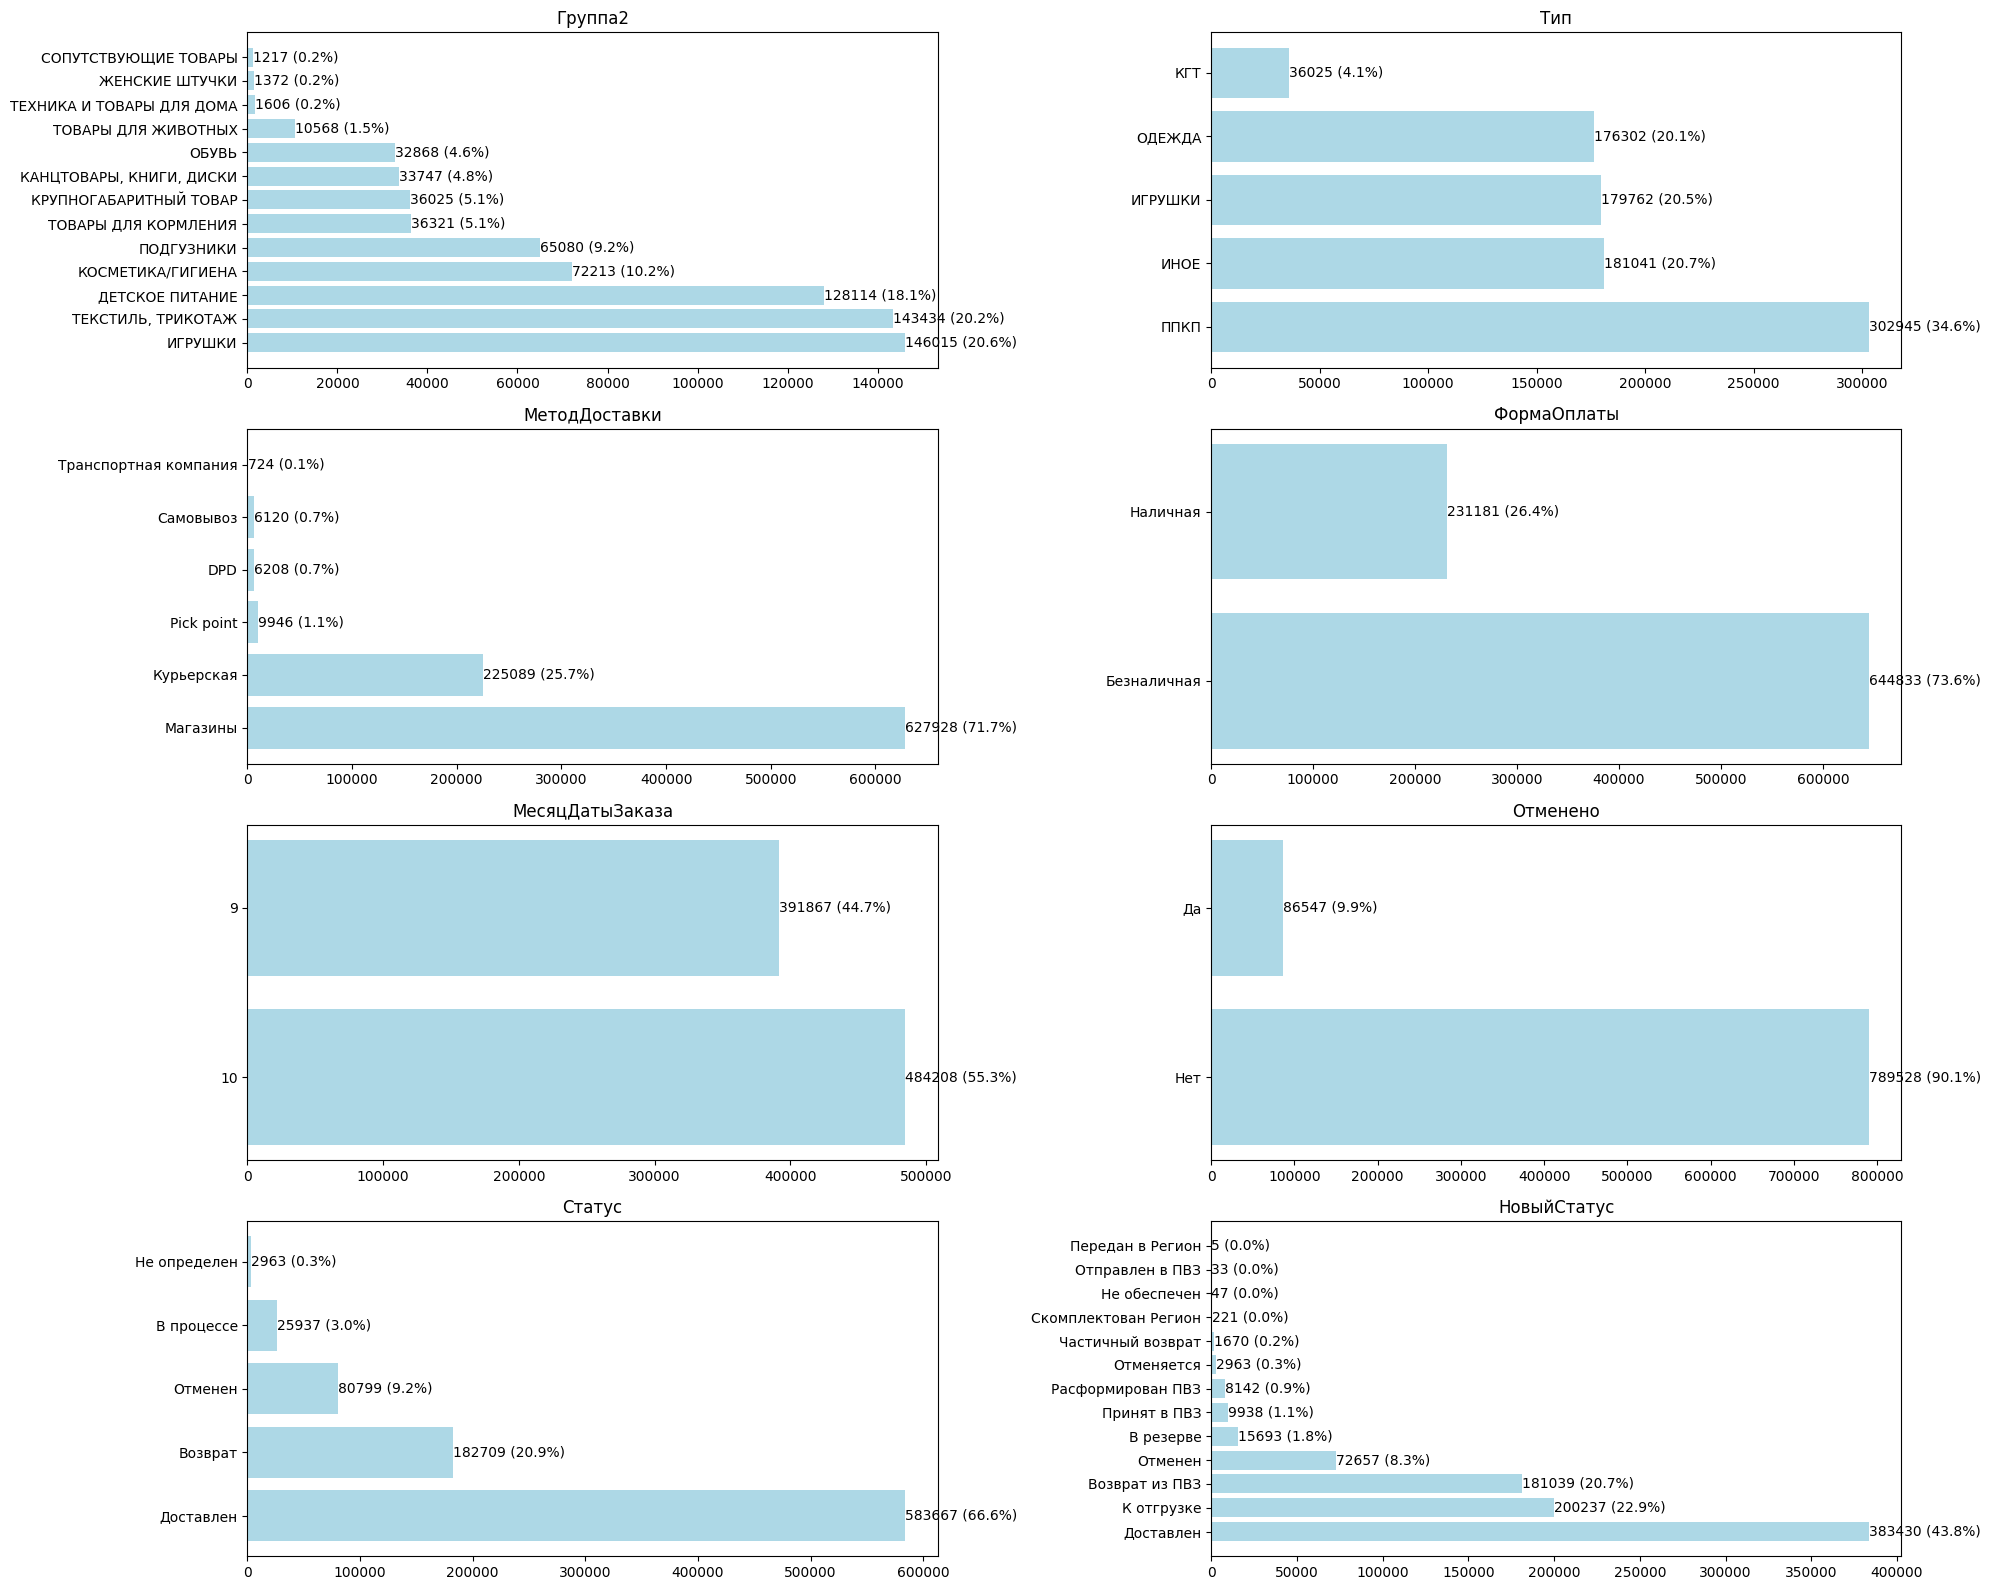

In [21]:
import matplotlib.pyplot as plt

cols = ['Группа2','Тип', 'МетодДоставки', 'ФормаОплаты',  
         'МесяцДатыЗаказа', 'Отменено',  'Статус', 'НовыйСтатус']

fig, axes = plt.subplots(4, 2, figsize=(20, 16))
axes = axes.flatten()

for idx, col in enumerate(cols):
    ax = axes[idx]
    
    counts = df[col].value_counts()
    total = counts.sum()
    
    # Горизонтальные столбцы голубого цвета
    bars = ax.barh(range(len(counts)), counts.values, color='lightblue')
    
    # Добавляем значения и проценты
    for i, count in enumerate(counts.values):
        percentage = (count / total) * 100
        ax.text(count + 5, i, f'{count} ({percentage:.1f}%)', 
                ha='left', va='center', fontsize=10)
    
    ax.set_title(col)
    ax.set_yticks(range(len(counts)))
    ax.set_yticklabels(counts.index)

plt.tight_layout()
plt.show()

In [22]:
df_time_09 = df[df['МесяцДатыЗаказа'] == 9]

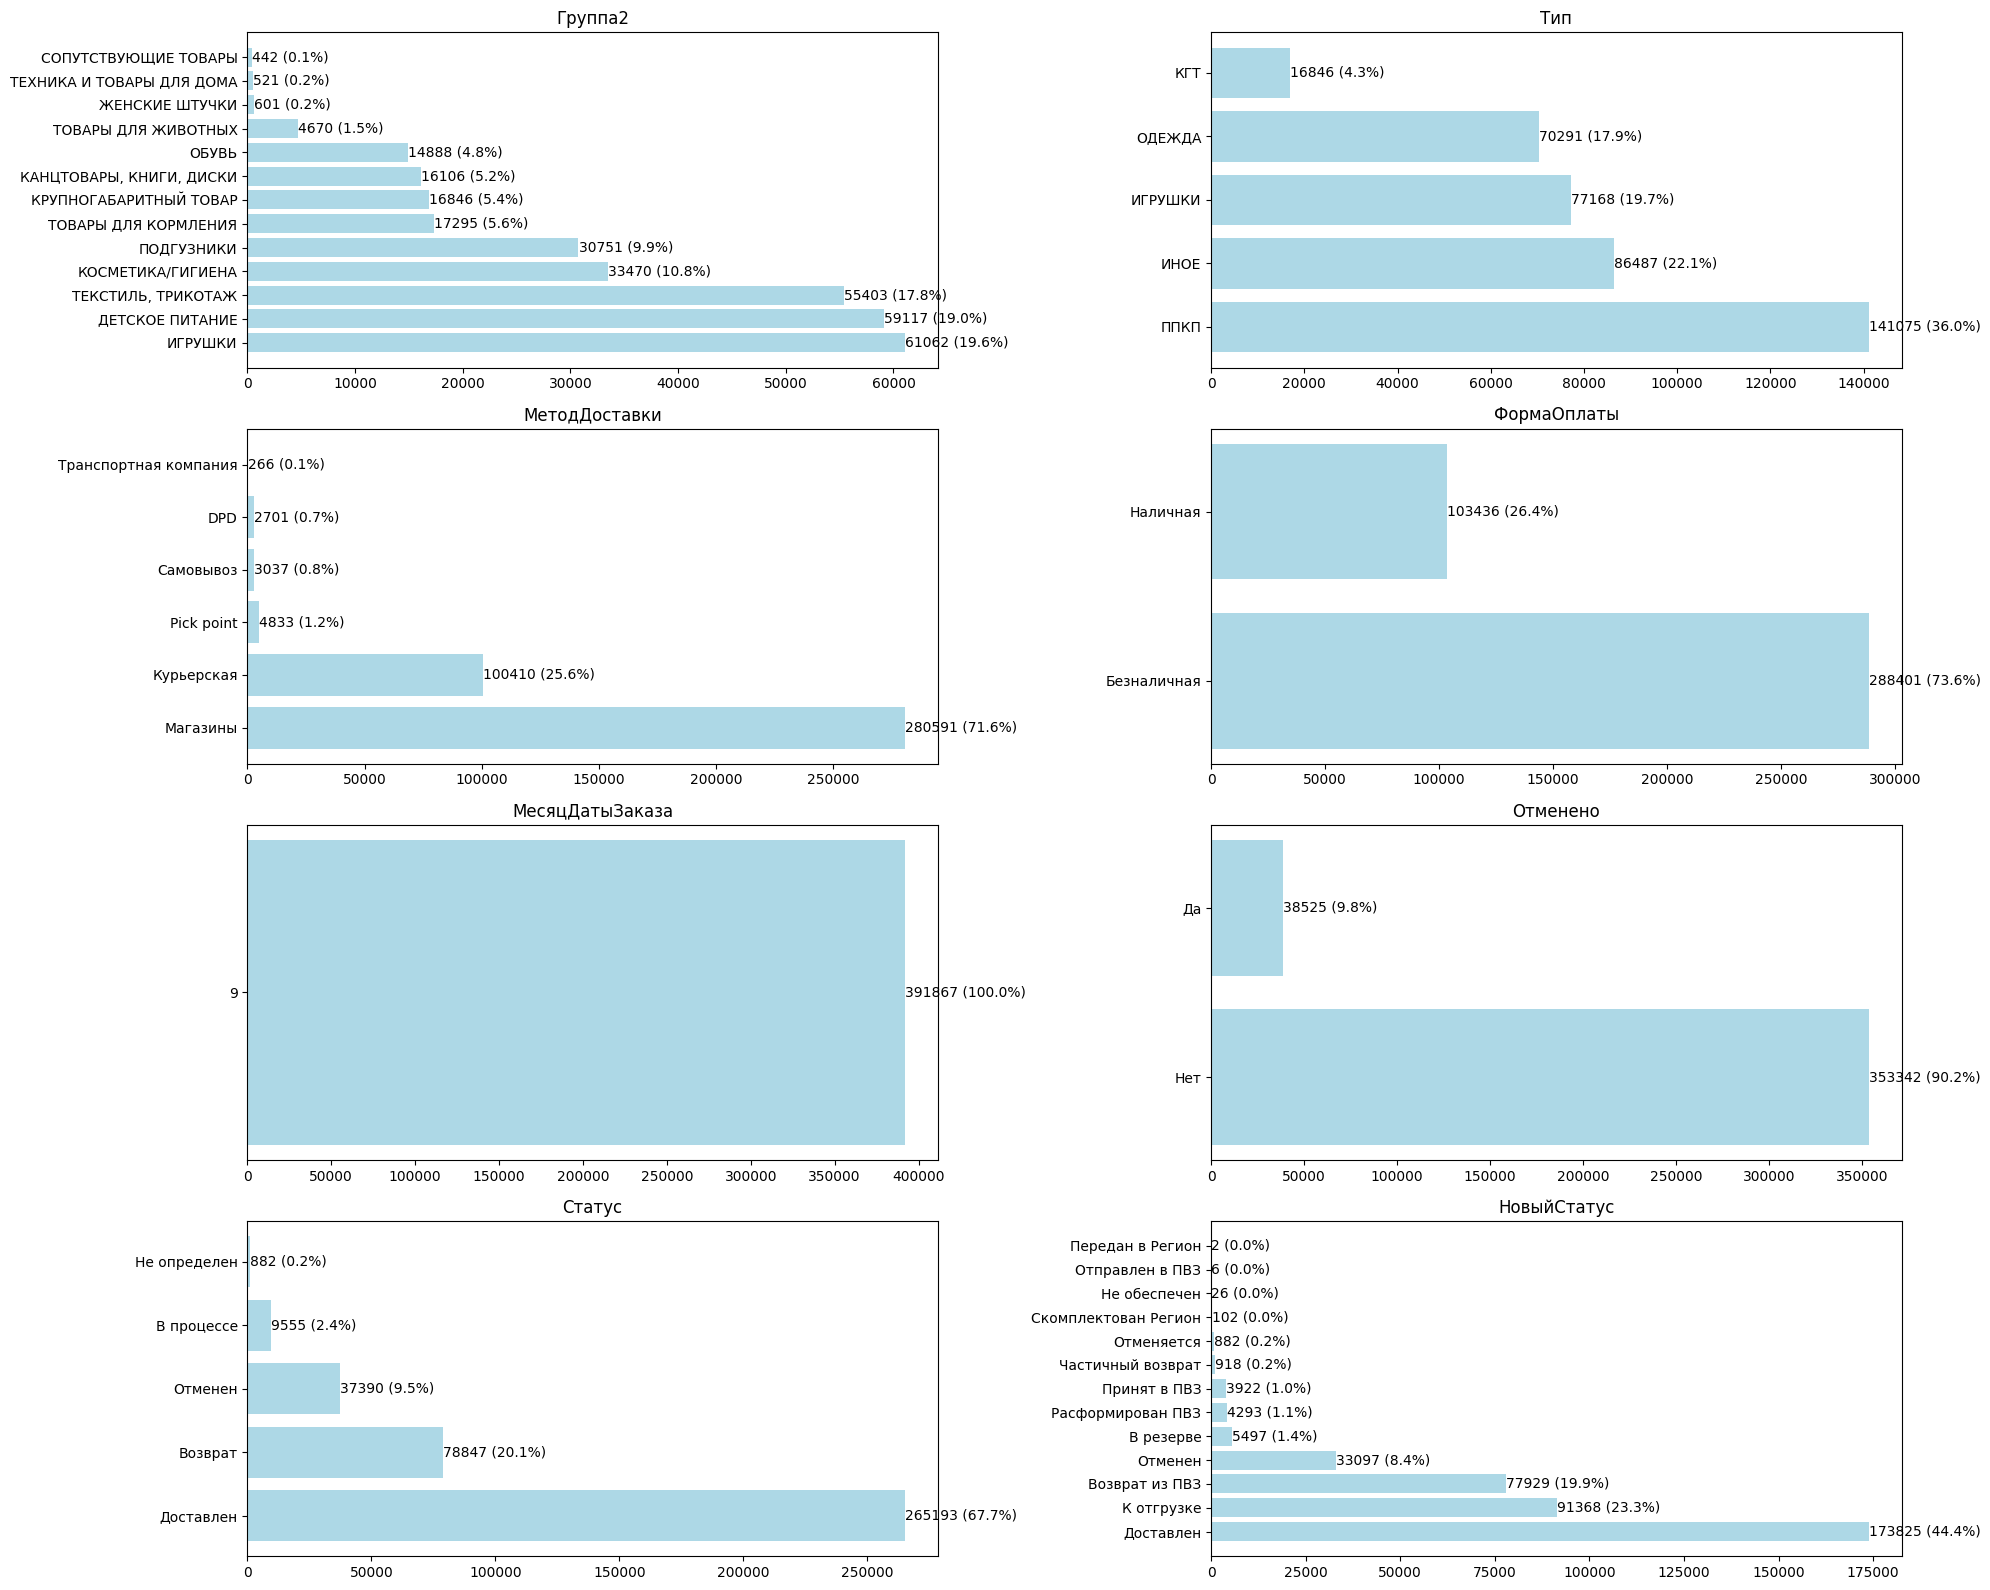

In [23]:
import matplotlib.pyplot as plt

cols = ['Группа2','Тип', 'МетодДоставки', 'ФормаОплаты',  
         'МесяцДатыЗаказа', 'Отменено',  'Статус', 'НовыйСтатус']

fig, axes = plt.subplots(4, 2, figsize=(20, 16))
axes = axes.flatten()

for idx, col in enumerate(cols):
    ax = axes[idx]
    
    counts = df_time_09[col].value_counts()
    total = counts.sum()
    
    # Горизонтальные столбцы голубого цвета
    bars = ax.barh(range(len(counts)), counts.values, color='lightblue')
    
    # Добавляем значения и проценты
    for i, count in enumerate(counts.values):
        percentage = (count / total) * 100
        ax.text(count + 5, i, f'{count} ({percentage:.1f}%)', 
                ha='left', va='center', fontsize=10)
    
    ax.set_title(col)
    ax.set_yticks(range(len(counts)))
    ax.set_yticklabels(counts.index)

plt.tight_layout()
plt.show()

In [24]:
numeric_data = []
for col in df_time_09.columns:
    total_rows = len(df)
    
    col_data = df_time_09[col]
    unique_count = col_data.nunique() 
    zeros_count = (col_data == 0).sum()  
    nan_count = col_data.isna().sum()  

    unique_percent = round((unique_count / total_rows * 100), 1)
    zeros_percent = round((zeros_count / total_rows * 100), 1)
    nan_percent = round((nan_count / total_rows * 100), 1)
    
    if df_time_09[col].dtype in ['int64', 'float64']:
        clean_data = col_data.dropna()
        
        numeric_data.append([
            col,
            #unique_count, f"{unique_percent}%",
            zeros_count, f"{zeros_percent}%",
            nan_count, f"{nan_percent}%",
            round(clean_data.mean(), 2),
            round(clean_data.median(), 2),
            #round(clean_data.std(), 2),
            #round(clean_data.sum(), 2),
            round(clean_data.min(), 2),
            round(clean_data.max(), 2),
            
        ])

print(tabulate(numeric_data, 
                headers=['Column', 'Zeros', '% of_Zeros', 'NaNs', '% of_NaNs', 'Mean', 'Median', 'Min', 'Max'],
                tablefmt='orgtbl'))

| Column                   |   Zeros | % of_Zeros   |   NaNs | % of_NaNs   |    Mean |   Median |       Min |              Max |
|--------------------------+---------+--------------+--------+-------------+---------+----------+-----------+------------------|
| СуммаЗаказаНаСайте       |       0 | 0.0%         |      0 | 0.0%        | 5002.49 |   3037   |      1    |      1.59224e+06 |
| СуммаДокумента           |    2103 | 0.2%         |      0 | 0.0%        | 4255.79 |   2676   |      0    | 560293           |
| Количество               |   11527 | 1.3%         |      0 | 0.0%        |    1.44 |      1   |      0    |    340           |
| Цена                     |      14 | 0.0%         |      0 | 0.0%        |  763.52 |    172   |      0    | 107000           |
| СуммаСтроки              |    5498 | 0.6%         |      0 | 0.0%        |  847.33 |    202   |      0    |      1.58125e+06 |
| ЦенаЗакупки              |       0 | 0.0%         |  81732 | 9.3%        |  703.23 |    204.6 |

In [25]:
df_time_10 = df[df['МесяцДатыЗаказа'] == 10]

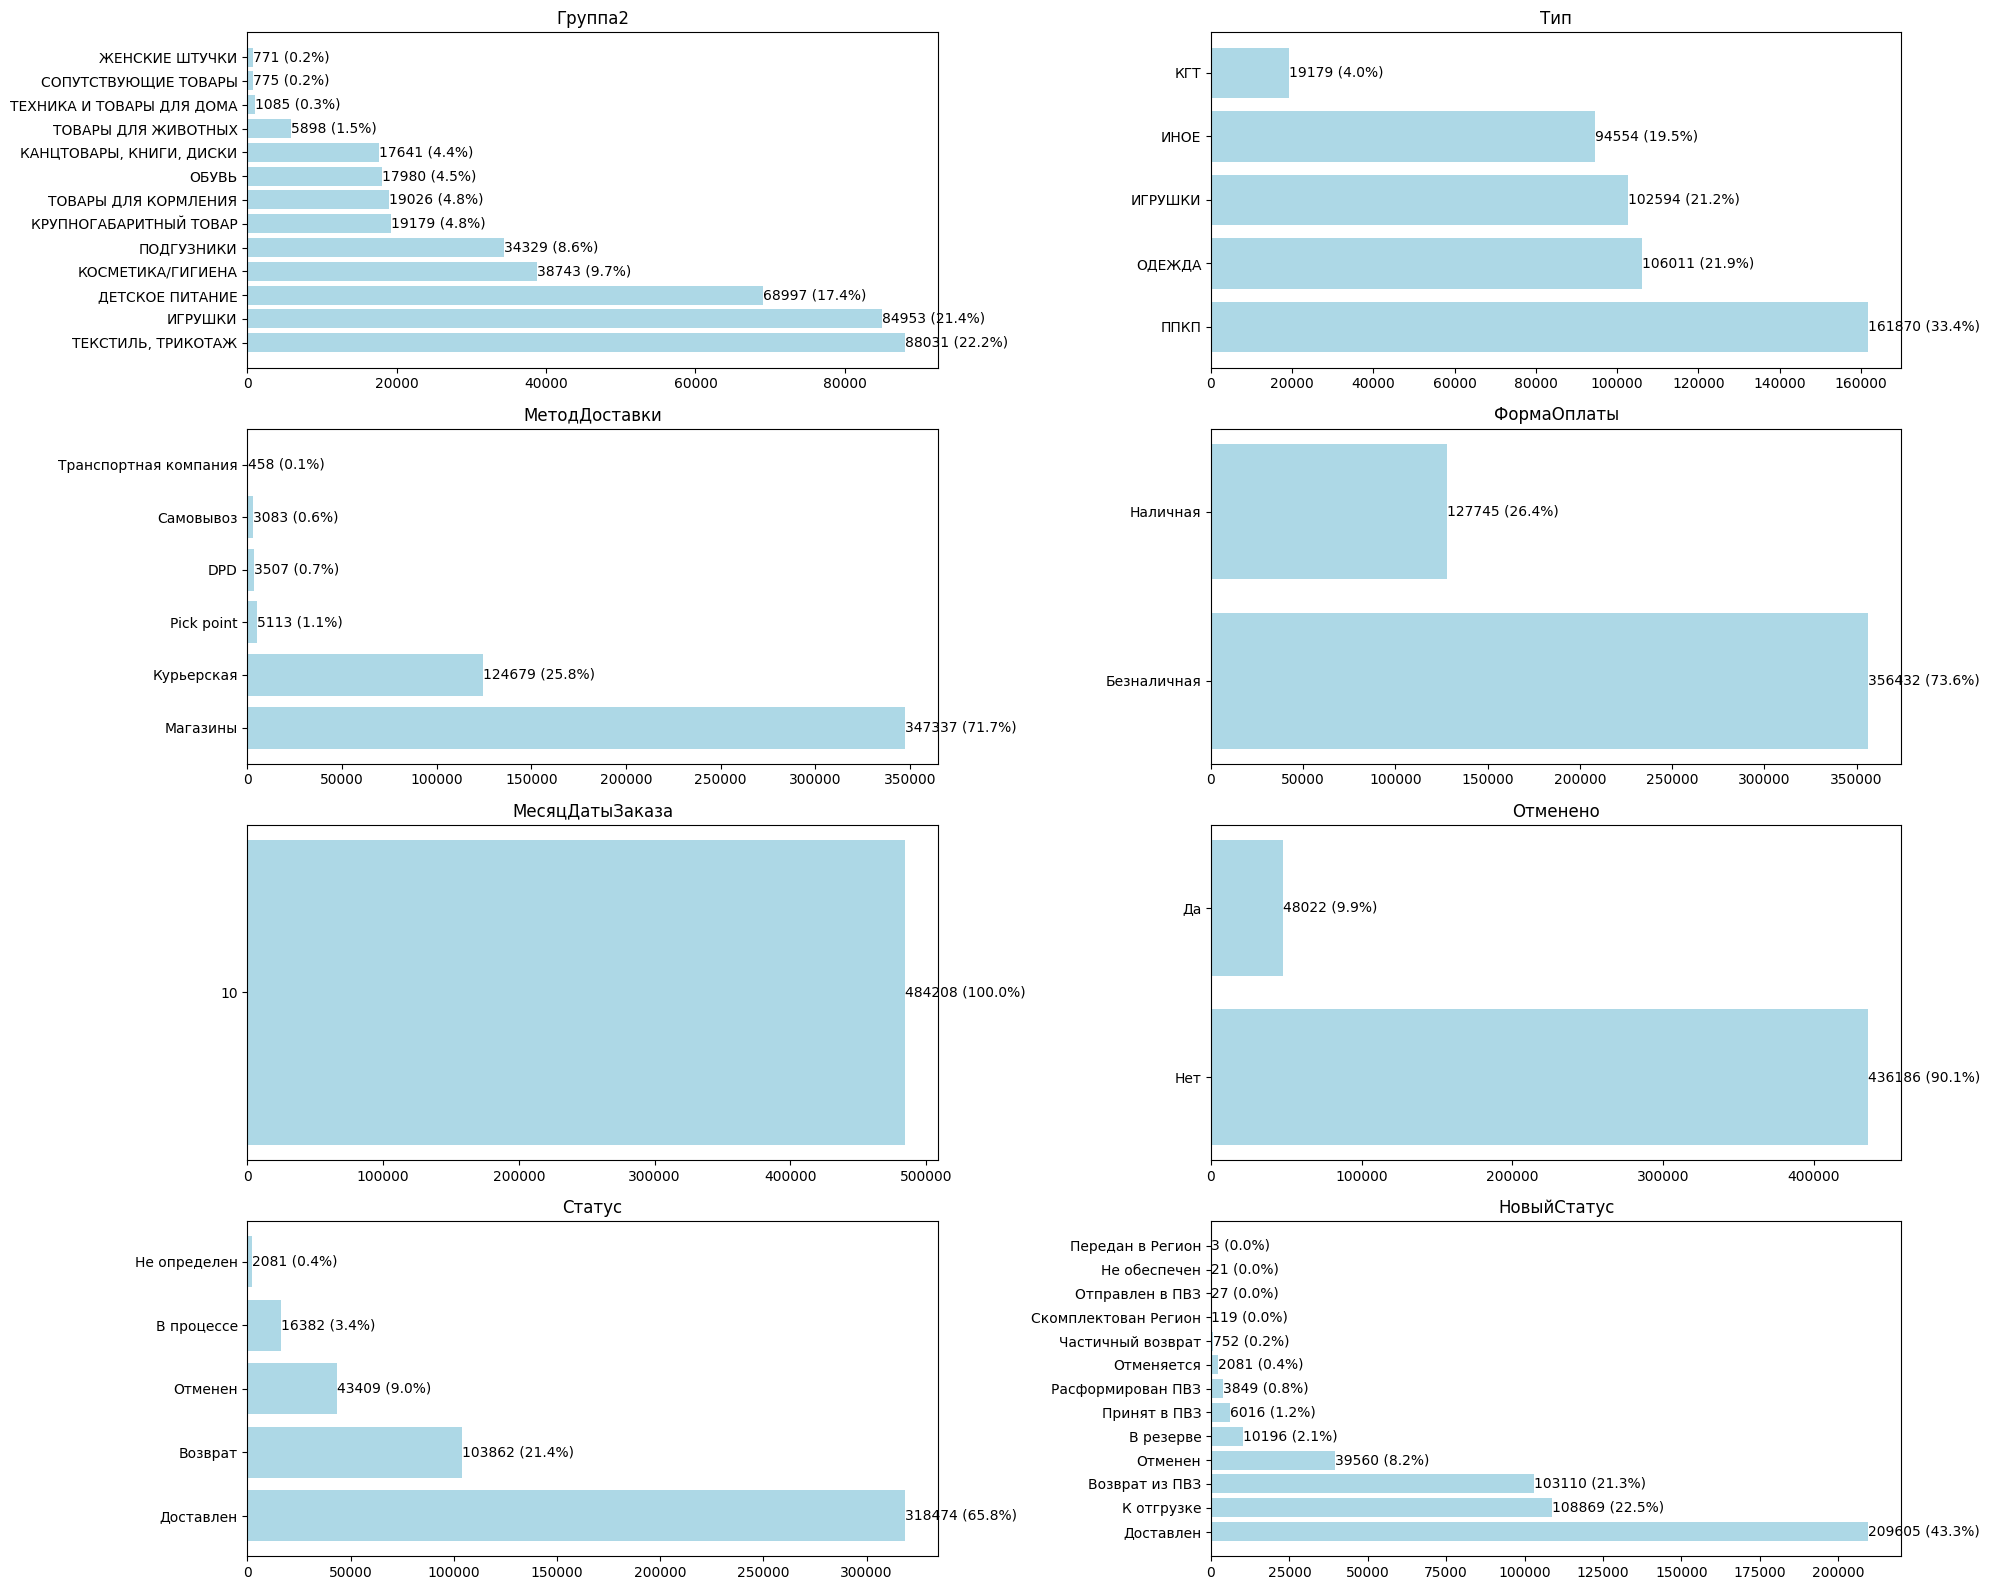

In [27]:
import matplotlib.pyplot as plt

cols = ['Группа2','Тип', 'МетодДоставки', 'ФормаОплаты',  
         'МесяцДатыЗаказа', 'Отменено',  'Статус', 'НовыйСтатус']

fig, axes = plt.subplots(4, 2, figsize=(20, 16))
axes = axes.flatten()

for idx, col in enumerate(cols):
    ax = axes[idx]
    
    counts = df_time_10[col].value_counts()
    total = counts.sum()
    
    # Горизонтальные столбцы голубого цвета
    bars = ax.barh(range(len(counts)), counts.values, color='lightblue')
    
    # Добавляем значения и проценты
    for i, count in enumerate(counts.values):
        percentage = (count / total) * 100
        ax.text(count + 5, i, f'{count} ({percentage:.1f}%)', 
                ha='left', va='center', fontsize=10)
    
    ax.set_title(col)
    ax.set_yticks(range(len(counts)))
    ax.set_yticklabels(counts.index)

plt.tight_layout()
plt.show()

In [28]:
numeric_data = []
for col in df_time_10.columns:
    total_rows = len(df)
    
    col_data = df_time_10[col]
    unique_count = col_data.nunique() 
    zeros_count = (col_data == 0).sum()  
    nan_count = col_data.isna().sum()  

    unique_percent = round((unique_count / total_rows * 100), 1)
    zeros_percent = round((zeros_count / total_rows * 100), 1)
    nan_percent = round((nan_count / total_rows * 100), 1)
    
    if df_time_10[col].dtype in ['int64', 'float64']:
        clean_data = col_data.dropna()
        
        numeric_data.append([
            col,
            #unique_count, f"{unique_percent}%",
            zeros_count, f"{zeros_percent}%",
            nan_count, f"{nan_percent}%",
            round(clean_data.mean(), 2),
            round(clean_data.median(), 2),
            #round(clean_data.std(), 2),
            round(clean_data.min(), 2),
            round(clean_data.max(), 2),
        ])

print(tabulate(numeric_data, 
                headers=['Column', 'Zeros', '% of_Zeros', 'NaNs', '% of_NaNs', 'Mean', 'Median', 'Min', 'Max'],
                tablefmt='orgtbl'))

| Column                   |   Zeros | % of_Zeros   |   NaNs | % of_NaNs   |    Mean |   Median |      Min |    Max |
|--------------------------+---------+--------------+--------+-------------+---------+----------+----------+--------|
| СуммаЗаказаНаСайте       |       0 | 0.0%         |      0 | 0.0%        | 5093.6  |  2989    |     10   | 944194 |
| СуммаДокумента           |    7913 | 0.9%         |      0 | 0.0%        | 4295.65 |  2632    |      0   |  94655 |
| Количество               |   14379 | 1.6%         |      0 | 0.0%        |    1.41 |     1    |      0   |    300 |
| Цена                     |      14 | 0.0%         |      0 | 0.0%        |  813.46 |   199    |      0   | 107000 |
| СуммаСтроки              |    7706 | 0.9%         |      0 | 0.0%        |  884.84 |   225    |      0   | 196080 |
| ЦенаЗакупки              |       0 | 0.0%         |  88138 | 10.1%       |  719.7  |   218.41 |      0.1 |  85700 |
| МесяцДатыЗаказа          |       0 | 0.0%         |   

In [29]:
def columnValues(df):

    total_rows = len(df)

    unique_count = df.nunique()
    zeros_count = (df == 0).sum(axis=0)
    nan_count = df.isna().sum()

    # Рассчитываем проценты
    unique_percent = round((unique_count / total_rows * 100), 1)
    zeros_percent = round((zeros_count / total_rows * 100), 1)
    nan_percent = round((nan_count / total_rows * 100), 1)
    data_types = df.dtypes

    # Формируем строку: каждая метрика сразу со своим процентом
    row = [unique_count, f"{unique_percent}%",
           zeros_count, f"{zeros_percent}%",
           nan_count, f"{nan_percent}%",
           data_types]
    return row

data = []
for column in df.columns:
    data.append([column] + columnValues(df[column]))

print(tabulate(data, headers=['Column', 'Unique', '% of_Unique', 'Zeros', '% of_Zeros', 'NaNs', '% of_NaNs', 'dtype'],
               tablefmt='orgtbl'))

| Column                   |   Unique | % of_Unique   |   Zeros | % of_Zeros   |   NaNs | % of_NaNs   | dtype   |
|--------------------------+----------+---------------+---------+--------------+--------+-------------+---------|
| Дата                     |    25648 | 2.9%          |       0 | 0.0%         |      0 | 0.0%        | object  |
| ДатаДоставки             |      112 | 0.0%          |       0 | 0.0%         |    548 | 0.1%        | object  |
| НомерЗаказаНаСайте       |   199457 | 22.8%         |       0 | 0.0%         |      0 | 0.0%        | object  |
| НовыйСтатус              |       13 | 0.0%          |       0 | 0.0%         |      0 | 0.0%        | object  |
| СуммаЗаказаНаСайте       |    17379 | 2.0%          |       0 | 0.0%         |      0 | 0.0%        | float64 |
| СуммаДокумента           |    16009 | 1.8%          |   10016 | 1.1%         |      0 | 0.0%        | float64 |
| МетодДоставки            |        6 | 0.0%          |       0 | 0.0%         |     60 

In [83]:
# Список колонок с пропусками
columns_with_missing = [
    'Группа2', 
    'ДатаДоставки',
    'МетодДоставки',
    'ФормаОплаты',  
    'Регион',  
    'Группа4',  
    'Маржа', 
    'ЭлектроннаяПочта_new' ,
    'Клиент'
]

# Удаляем строки с пропусками в этих колонках
print(f"\nДо удаления: {len(df)} строк")
df_clean = df.dropna(subset=columns_with_missing)
print(f"После удаления: {len(df_clean)} строк")
print(f"Удалено строк: {len(df) - len(df_clean)}")

# Проверяем результат
print("\nПроверка пропусков после удаления:")
for col in columns_with_missing:
    missing = df_clean[col].isna().sum()
    print(f"{col}: {missing} пропусков")


До удаления: 873816 строк
После удаления: 663854 строк
Удалено строк: 209962

Проверка пропусков после удаления:
Группа2: 0 пропусков
ДатаДоставки: 0 пропусков
МетодДоставки: 0 пропусков
ФормаОплаты: 0 пропусков
Регион: 0 пропусков
Группа4: 0 пропусков
Маржа: 0 пропусков
ЭлектроннаяПочта_new: 0 пропусков
Клиент: 0 пропусков


In [48]:
def columnValues(df_clean):

    total_rows = len(df_clean)

    unique_count = df_clean.nunique()
    zeros_count = (df_clean == 0).sum(axis=0)
    nan_count = df_clean.isna().sum()

    # Рассчитываем проценты
    unique_percent = round((unique_count / total_rows * 100), 1)
    zeros_percent = round((zeros_count / total_rows * 100), 1)
    nan_percent = round((nan_count / total_rows * 100), 1)
    data_types = df_clean.dtypes

    # Формируем строку: каждая метрика сразу со своим процентом
    row = [unique_count, f"{unique_percent}%",
           zeros_count, f"{zeros_percent}%",
           nan_count, f"{nan_percent}%",
           data_types]
    return row

data = []
for column in df_clean.columns:
    data.append([column] + columnValues(df_clean[column]))

print(tabulate(data, headers=['Column', 'Unique', '% of_Unique', 'Zeros', '% of_Zeros', 'NaNs', '% of_NaNs', 'dtype'],
               tablefmt='orgtbl'))

| Column                   |   Unique | % of_Unique   |   Zeros | % of_Zeros   |   NaNs | % of_NaNs   | dtype   |
|--------------------------+----------+---------------+---------+--------------+--------+-------------+---------|
| Дата                     |    22764 | 3.4%          |       0 | 0.0%         |      0 | 0.0%        | object  |
| ДатаДоставки             |      108 | 0.0%          |       0 | 0.0%         |      0 | 0.0%        | object  |
| НомерЗаказаНаСайте       |   185416 | 27.9%         |       0 | 0.0%         |      0 | 0.0%        | object  |
| НовыйСтатус              |       13 | 0.0%          |       0 | 0.0%         |      0 | 0.0%        | object  |
| СуммаЗаказаНаСайте       |    16609 | 2.5%          |       0 | 0.0%         |      0 | 0.0%        | float64 |
| СуммаДокумента           |    15301 | 2.3%          |    8656 | 1.3%         |      0 | 0.0%        | float64 |
| МетодДоставки            |        6 | 0.0%          |       0 | 0.0%         |      0 

In [84]:
df_clean = df_clean.drop(columns=['МагазинЗаказа'])
df_clean = df_clean.drop(columns=['ПричинаОтмены'])
df_clean = df_clean.drop(columns=['ГородМагазина'])

In [85]:
df_clean = df_clean.drop(columns=['ПВЗ_код'])

In [ ]:
#количество = 0 там где возврат или автокорректировка

In [ ]:
object_cols = df_clean.select_dtypes(include=['object']).columns

print("КАТЕГОРИАЛЬНЫЕ КОЛОНКИ И ИХ ЗНАЧЕНИЯ:")

for col in object_cols:
    unique_count = df_clean[col].nunique()
    print(f"\n{col}:")
    print(f"  Уникальных: {unique_count}, Пропусков: {df_clean[col].isna().sum()}")
    
    if unique_count <= 10:
        vals = df_clean[col].dropna().unique()
        print(f"  Значения: {sorted(vals)}")
    elif unique_count <= 50:
        print(f"  Первые 10 значений: {sorted(df_clean[col].dropna().unique()[:10])}")
    else:
        print(f"  Слишком много значений ({unique_count}), показываем примеры")
        print(f"  Примеры: {sorted(df_clean[col].dropna().unique()[:5])} ")


In [28]:
def columnValues(df_clean):

    total_rows = len(df_clean)

    unique_count = df_clean.nunique()
    zeros_count = (df_clean == 0).sum(axis=0)
    nan_count = df_clean.isna().sum()

    # Рассчитываем проценты
    unique_percent = round((unique_count / total_rows * 100), 1)
    zeros_percent = round((zeros_count / total_rows * 100), 1)
    nan_percent = round((nan_count / total_rows * 100), 1)
    data_types = df_clean.dtypes

    # Формируем строку: каждая метрика сразу со своим процентом
    row = [unique_count, f"{unique_percent}%",
           zeros_count, f"{zeros_percent}%",
           nan_count, f"{nan_percent}%",
           data_types]
    return row

data = []
for column in df_clean.columns:
    data.append([column] + columnValues(df_clean[column]))

print(tabulate(data, headers=['Column', 'Unique', '% of_Unique', 'Zeros', '% of_Zeros', 'NaNs', '% of_NaNs', 'dtype'],
               tablefmt='orgtbl'))

| Column                              |   Unique | % of_Unique   |   Zeros | % of_Zeros   |   NaNs | % of_NaNs   | dtype   |
|-------------------------------------+----------+---------------+---------+--------------+--------+-------------+---------|
| Дата                                |    22470 | 3.5%          |       0 | 0.0%         |      0 | 0.0%        | object  |
| ДатаДоставки                        |      108 | 0.0%          |       0 | 0.0%         |      0 | 0.0%        | object  |
| НомерЗаказаНаСайте                  |   182097 | 28.5%         |       0 | 0.0%         |      0 | 0.0%        | object  |
| СуммаЗаказаНаСайте                  |    16550 | 2.6%          |       0 | 0.0%         |      0 | 0.0%        | float64 |
| СуммаДокумента                      |    15298 | 2.4%          |    6032 | 0.9%         |      0 | 0.0%        | float64 |
| ФормаОплаты                         |        2 | 0.0%          |       0 | 0.0%         |      0 | 0.0%        | object  |


In [32]:

df_clean = df_clean.query('Количество != 0')

In [33]:
# 1. Создаем маску с условиями для выкупов
mask = (df_clean['Отменено'] == 'Нет') & \
       (df_clean['Статус'] == 'Доставлен') & \
       (df_clean['НовыйСтатус'] == 'Доставлен')

# 2. Считаем выкупы по группам
sales_dostavleno = df_clean[mask].groupby('Группа2')['КоличествоПроданоКлиенту'].sum()

# 3. Создаем итоговую таблицу со всеми нужными колонками
df_result = df_clean.groupby('Группа2').agg(
    Количество_товаров=('Количество', 'sum'),
    Среднее_количество_в_строке=('Количество', 'mean'),
    Выручка=('СуммаСтроки', 'sum'),
    Средняя_стоимость=('СуммаСтроки', 'mean'),
    Количество_Продано=('КоличествоПроданоКлиенту', 'sum'),
    Средняя_маржа=('Маржа', 'mean'),
    Общая_маржа=('Маржа', 'sum'),
    Количество_записей=('ID_SKU', 'count')
).reset_index()

# 4. Добавляем количество выкупов
df_result['количество_выкупов'] = df_result['Группа2'].map(sales_dostavleno).fillna(0)

# 5. Добавляем процент выкупа
df_result['процент_выкупа_%'] = (df_result['количество_выкупов'] / 
                                  df_result['Количество_Продано'] * 100).round(2)

# 6. Добавляем маржу процент (если нужно)
df_result['маржа_процент'] = (df_result['Общая_маржа'] / 
                               df_result['Выручка'] * 100).round(2)

# 7. Сортируем и округляем
df_result = df_result.round(2)

# 8. Смотрим результат
df_result

,Группа2,Количество_товаров,Среднее_количество_в_строке,Выручка,Средняя_стоимость,Количество_Продано,Средняя_маржа,Общая_маржа,Количество_записей,количество_выкупов,процент_выкупа_%,маржа_процент
0,ДЕТСКОЕ ПИТАНИЕ,320784,3.04,18543462.0,175.46,299816,10.44,1103499.73,105686,116939,39.00,5.95
1,ЖЕНСКИЕ ШТУЧКИ,1178,1.15,154162.0,149.96,1001,79.82,82056.87,1028,478,47.75,53.23
2,ИГРУШКИ,158549,1.18,102708914.0,767.58,133597,141.66,18955510.99,133809,75537,56.54,18.46
3,"КАНЦТОВАРЫ, КНИГИ, ДИСКИ",55653,1.77,7966979.0,253.01,49328,68.47,2155925.37,31489,24014,48.68,27.06
4,КОСМЕТИКА/ГИГИЕНА,95637,1.37,17487630.0,249.94,87863,38.42,2688414.36,69966,36846,41.94,15.37
5,КРУПНОГАБАРИТНЫЙ ТОВАР,29596,1.02,154499304.0,5342.67,24595,1329.38,38443146.91,28918,13560,55.13,24.88
6,ОБУВЬ,29827,1.01,41502048.0,1402.10,17714,486.48,14399949.82,29600,7780,43.92,34.70
7,ПОДГУЗНИКИ,87451,1.49,88243312.0,1507.43,78129,-29.27,-1713461.20,58539,46665,59.73,-1.94
8,СОПУТСТВУЮЩИЕ ТОВАРЫ,850,1.10,230754.0,299.68,683,116.96,90061.90,770,293,42.90,39.03
9,"ТЕКСТИЛЬ, ТРИКОТАЖ",139005,1.04,169537270.0,1267.05,101263,485.74,64994519.05,133805,48201,47.60,38.34


In [97]:
df_clean.head()

,Дата,ДатаДоставки,НомерЗаказаНаСайте,НовыйСтатус,СуммаЗаказаНаСайте,СуммаДокумента,МетодДоставки,ФормаОплаты,Регион,Группа2,Группа3,Группа4,Тип,Номенклатура,ТипТовара,Отменено,Количество,Цена,СуммаСтроки,ЦенаЗакупки,МесяцДатыЗаказа,ГодДатыЗаказа,Статус,Гео,Маржа,СуммаУслуг,СуммаДоставки,НомерСтроки,КоличествоПроданоКлиенту,ДатаЗаказаНаСайте,Телефон_new,ЭлектроннаяПочта_new,Клиент,ID_SKU,Date
1,2017-09-01,08.09.2017 0:00,5412440_TR,Отменен,2614.0,150.0,Курьерская,0.0,Москва,ИГРУШКИ,ИГРУШКИ ДЛЯ ДЕВОЧЕК,наборы игровые,ИГРУШКИ,"PLAYSKOOL, ИГРУШКА Музыкальный замок Пони",1.0,1.0,1,1382.0,1382.0,1974.00,9,2 017,Отменен,Москва,-592.00,150.0,150.0,2,1,31.08.2017 0:00,55574851-49485350505178,103117_gu12@mail.ru,Валентина,IDL00021467250,2017-09-01
2,2017-09-01,08.09.2017 0:00,5412440_TR,Отменен,2614.0,150.0,Курьерская,0.0,Москва,ИГРУШКИ,ИГРУШКИ ДЛЯ ДЕВОЧЕК,наборы игровые,ИГРУШКИ,"MY LITTLE PONY, НАБОР игровой Поезд Дружбы",1.0,1.0,1,843.0,843.0,1685.20,9,2 017,Отменен,Москва,-842.20,150.0,150.0,1,1,31.08.2017 0:00,55574851-49485350505178,103117_gu12@mail.ru,Валентина,IDL00036071149,2017-09-01
3,2017-09-01,08.09.2017 0:00,5412440_TR,Отменен,2614.0,150.0,Курьерская,0.0,Москва,ИГРУШКИ,ИГРУШКИ ДЛЯ РАЗВИТИЯ МАЛЫШЕЙ,прочие игрушки для развития,ИГРУШКИ,"УМКА , ЧАСЫ Фиксики, с проекцией",1.0,1.0,1,239.0,239.0,154.98,9,2 017,Отменен,Москва,84.02,150.0,150.0,3,1,31.08.2017 0:00,55574851-49485350505178,103117_gu12@mail.ru,Валентина,IDL00038944553,2017-09-01
5,2017-09-01,11.09.2017 0:00,5412441_TR,Возврат из ПВЗ,4563.0,4563.0,Магазины,1.0,Санкт-Петербург,"КАНЦТОВАРЫ, КНИГИ, ДИСКИ",КАНЦТОВАРЫ,предметы для рисования,ИГРУШКИ,ДОСКА с задвижками Первые навыки,1.0,0.0,1,2495.0,2495.0,1747.00,9,2 017,Возврат,Регионы,748.00,99.0,99.0,1,0,31.08.2017 0:00,55575049-55525257485770,106117_ju17@mail.ru,Гость,ID9010014576553,2017-09-01
6,2017-09-01,11.09.2017 0:00,5412441_TR,Возврат из ПВЗ,4563.0,4563.0,Магазины,1.0,Санкт-Петербург,ИГРУШКИ,ИГРУШКИ ДЛЯ РАЗВИТИЯ МАЛЫШЕЙ,сортеры,ИГРУШКИ,"MELISSA&DOUG, ГАРАЖИ деревянные сортировщики",1.0,0.0,1,1969.0,1969.0,1519.00,9,2 017,Возврат,Регионы,450.00,99.0,99.0,2,0,31.08.2017 0:00,55575049-55525257485770,106117_ju17@mail.ru,Гость,IDL00048845957,2017-09-01


In [94]:
df_clean['Дата'] = pd.to_datetime(df_clean['Дата']).dt.date

# Убедимся, что дата в правильном формате
df_clean['Дата'] = pd.to_datetime(df_clean['Дата'])
df_clean['Date'] = df_clean['Дата'].dt.date

# Агрегация по дням и группам
daily = df_clean.groupby(['Date', 'Группа2'])['Количество'].sum().reset_index()
pivot = daily.pivot_table(index='Date', columns='Группа2', values='Количество', fill_value=0)

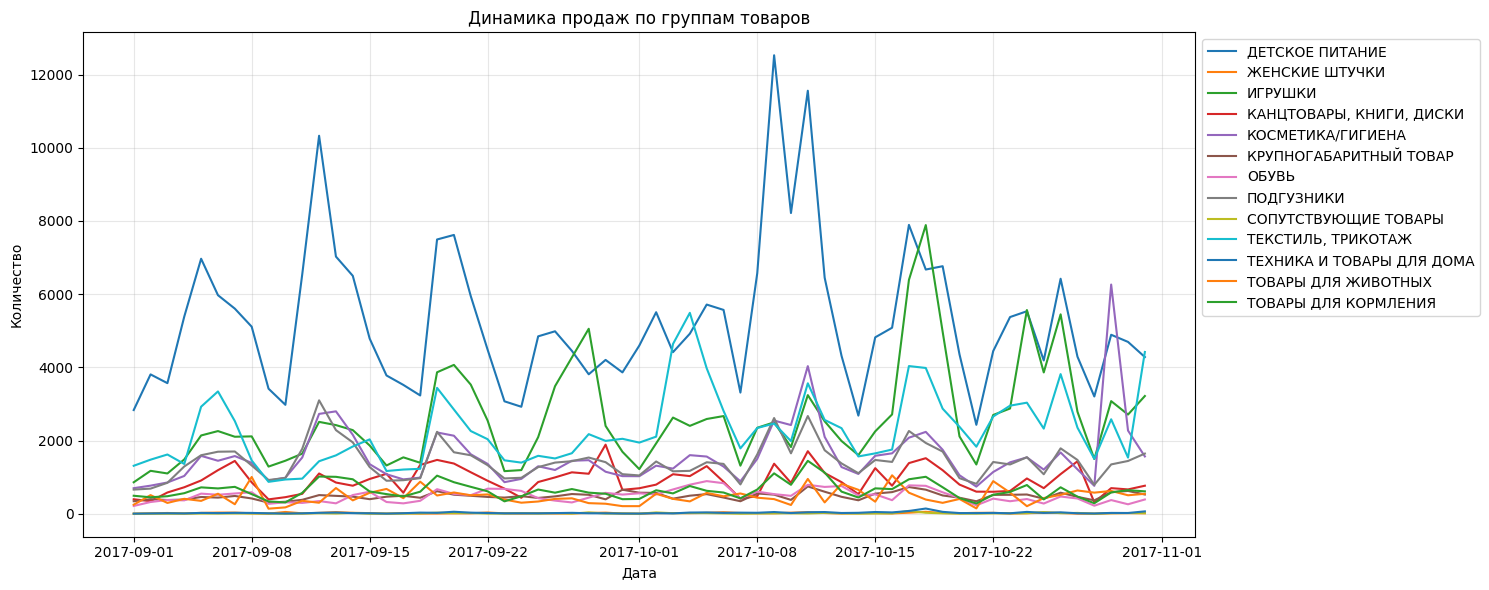

In [96]:
plt.figure(figsize=(15, 6))
pivot.plot(linewidth=1.5, ax=plt.gca())
plt.title('Динамика продаж по группам товаров')
plt.xlabel('Дата')
plt.ylabel('Количество')
plt.legend(loc='upper left', bbox_to_anchor=(1, 1))
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

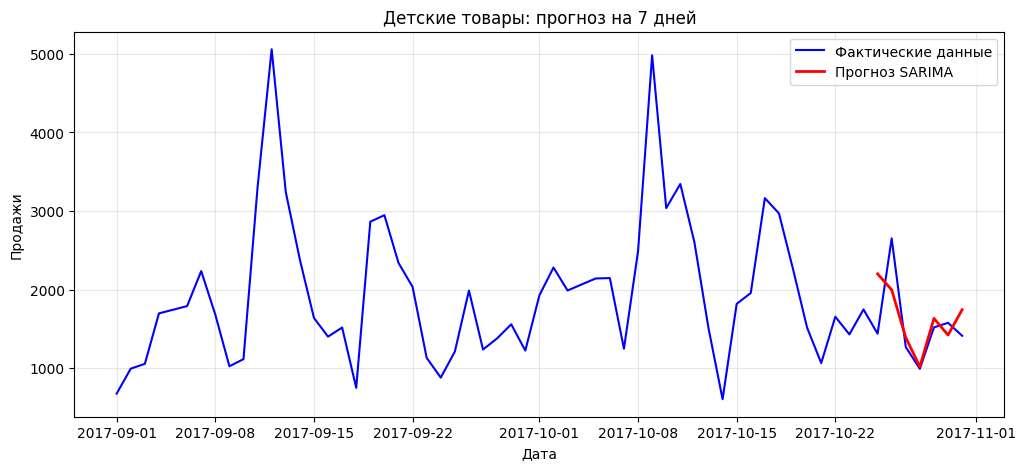

MAE: 309.03
r2: 0.28


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import r2_score
import warnings
warnings.filterwarnings('ignore')

# 1. Маска для выкупа 
mask = (df_clean['Отменено'] == 0) & \
       (df_clean['Статус'] == 'Доставлен') & \
       (df_clean['НовыйСтатус'] == 'Доставлен')


# 2. Данные по выкупленным товарам 
detstvo = df_clean[mask & (df_clean['Группа2'] == 'ДЕТСКОЕ ПИТАНИЕ')].groupby('Date')['КоличествоПроданоКлиенту'].sum()

# 2. Разделение
train = detstvo[:-7]
test = detstvo[-7:]

# 3. Модель
model = SARIMAX(train, order=(2,0,1), seasonal_order=(0,1,0,7))
results = model.fit(disp=False)
forecast = results.forecast(steps=7)

# 4. График
plt.figure(figsize=(12,5))

# Полный ряд (train + test) - синяя линия
plt.plot(detstvo.index, detstvo.values, 'b-', linewidth=1.5, label='Фактические данные')

# Прогноз на последние 7 дней - красная линия ПОВЕРХ
plt.plot(forecast.index, forecast.values, 'r-', linewidth=2, label='Прогноз SARIMA')

plt.title('Детские товары: прогноз на 7 дней')
plt.xlabel('Дата')
plt.ylabel('Продажи')
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

print(f'MAE: {mean_absolute_error(test, forecast):.2f}')
print(f'r2: {r2_score(test, forecast):.2f}')

In [ ]:
# Оптимальные пааметры для модели

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.stattools import adfuller
import warnings
warnings.filterwarnings('ignore')

# Ваши данные по детским товарам (выкупленные)
detstvo = df_clean[mask & (df_clean['Группа2'] == 'ДЕТСКОЕ ПИТАНИЕ')].groupby('Date')['КоличествоПроданоКлиенту'].sum()

# Проверка на стационарность (для определения d)
def check_stationarity(series, title):
    result = adfuller(series.dropna())
    print(f'{title}:')
    print(f'  ADF Statistic: {result[0]:.4f}')
    print(f'  p-value: {result[1]:.4f}')
    print(f'  Стационарен: {result[1] < 0.05}')
    return result[1] < 0.05

# Проверяем исходный ряд
is_stationary = check_stationarity(detstvo, 'Исходный ряд')

Исходный ряд:
  ADF Statistic: -4.4118
  p-value: 0.0003
  Стационарен: True


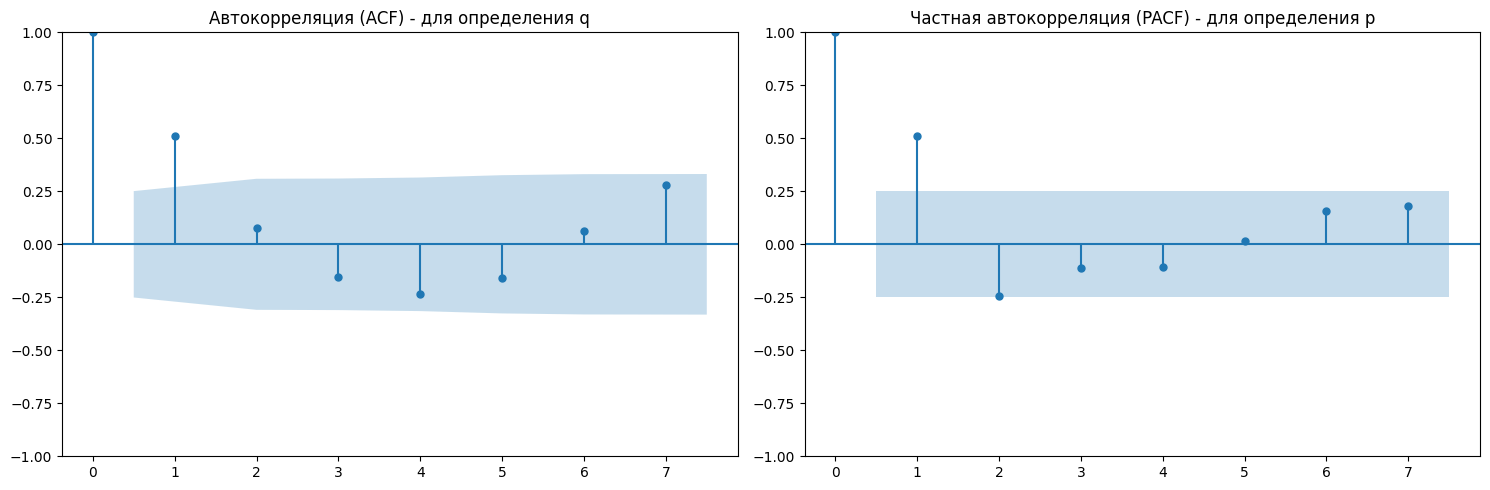


Сезонные лаги (7, 14, 21):
Лаг 7: 0.279
Лаг 14: -0.031
Лаг 21: 0.043
Лаг 28: 0.331


In [161]:
import matplotlib.pyplot as plt
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# ACF
plot_acf(detstvo, lags=7, ax=axes[0])
axes[0].set_title('Автокорреляция (ACF) - для определения q')

# PACF
plot_pacf(detstvo, lags=7, ax=axes[1])
axes[1].set_title('Частная автокорреляция (PACF) - для определения p')

plt.tight_layout()
plt.show()

# Анализ сезонности (проверяем лаги, кратные 7)
print("\nСезонные лаги (7, 14, 21):")
from statsmodels.tsa.stattools import acf
acf_vals = acf(detstvo, nlags=30)
for lag in [7, 14, 21, 28]:
    if lag < len(acf_vals):
        print(f"Лаг {lag}: {acf_vals[lag]:.3f}")

In [145]:
# 1. Посмотрите, что попадает в выборку
sample = df_clean[mask & (df_clean['Группа2'] == 'ДЕТСКОЕ ПИТАНИЕ')].head()
print("Пример записей, попадающих в выборку:")
print(sample[['Date', 'Группа2', 'КоличествоПроданоКлиенту', 'Статус', 'Отменено']])

Пример записей, попадающих в выборку:
Empty DataFrame
Columns: [Date, Группа2, КоличествоПроданоКлиенту, Статус, Отменено]
Index: []


MAE: 714.21
R²: 0.090


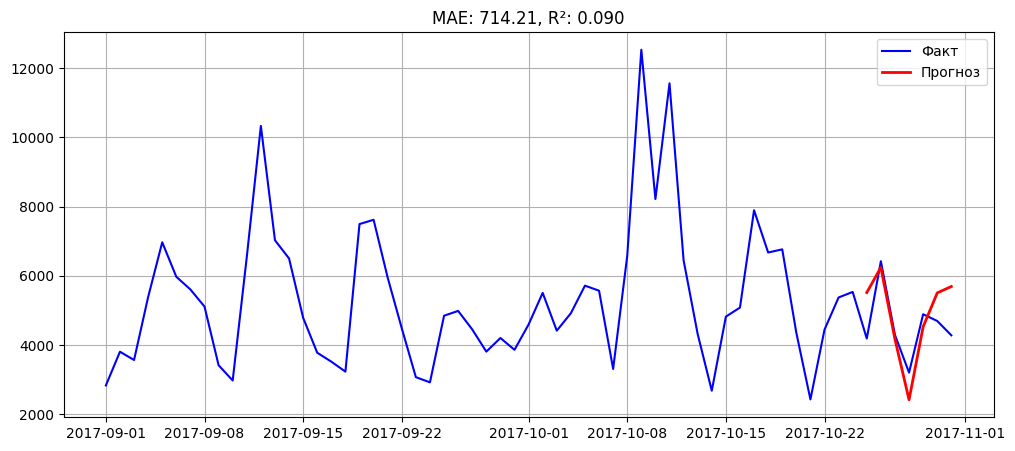

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.metrics import mean_absolute_error, r2_score
import warnings
warnings.filterwarnings('ignore')

# 1.
detstvo = df_clean[df_clean['Группа2'] == 'ДЕТСКОЕ ПИТАНИЕ'].groupby('Date')['Количество'].sum()

# 2. Разделение
train = detstvo[:-7]
test = detstvo[-7:]

# 3. Модель
model = SARIMAX(train, order=(1,1,1), seasonal_order=(0,1,0,7))
results = model.fit(disp=False)
forecast = results.forecast(steps=7)

# 4. Метрики
mae = mean_absolute_error(test, forecast)
r2 = r2_score(test, forecast)

print(f"MAE: {mae:.2f}")
print(f"R²: {r2:.3f}")

# 5. График
plt.figure(figsize=(12,5))
plt.plot(detstvo.index, detstvo.values, 'b-', linewidth=1.5, label='Факт')
plt.plot(forecast.index, forecast.values, 'r-', linewidth=2, label='Прогноз')
plt.title('Детские товары')
plt.legend()
plt.grid(True)
plt.show()

Анализируем группу: ДЕТСКОЕ ПИТАНИЕ


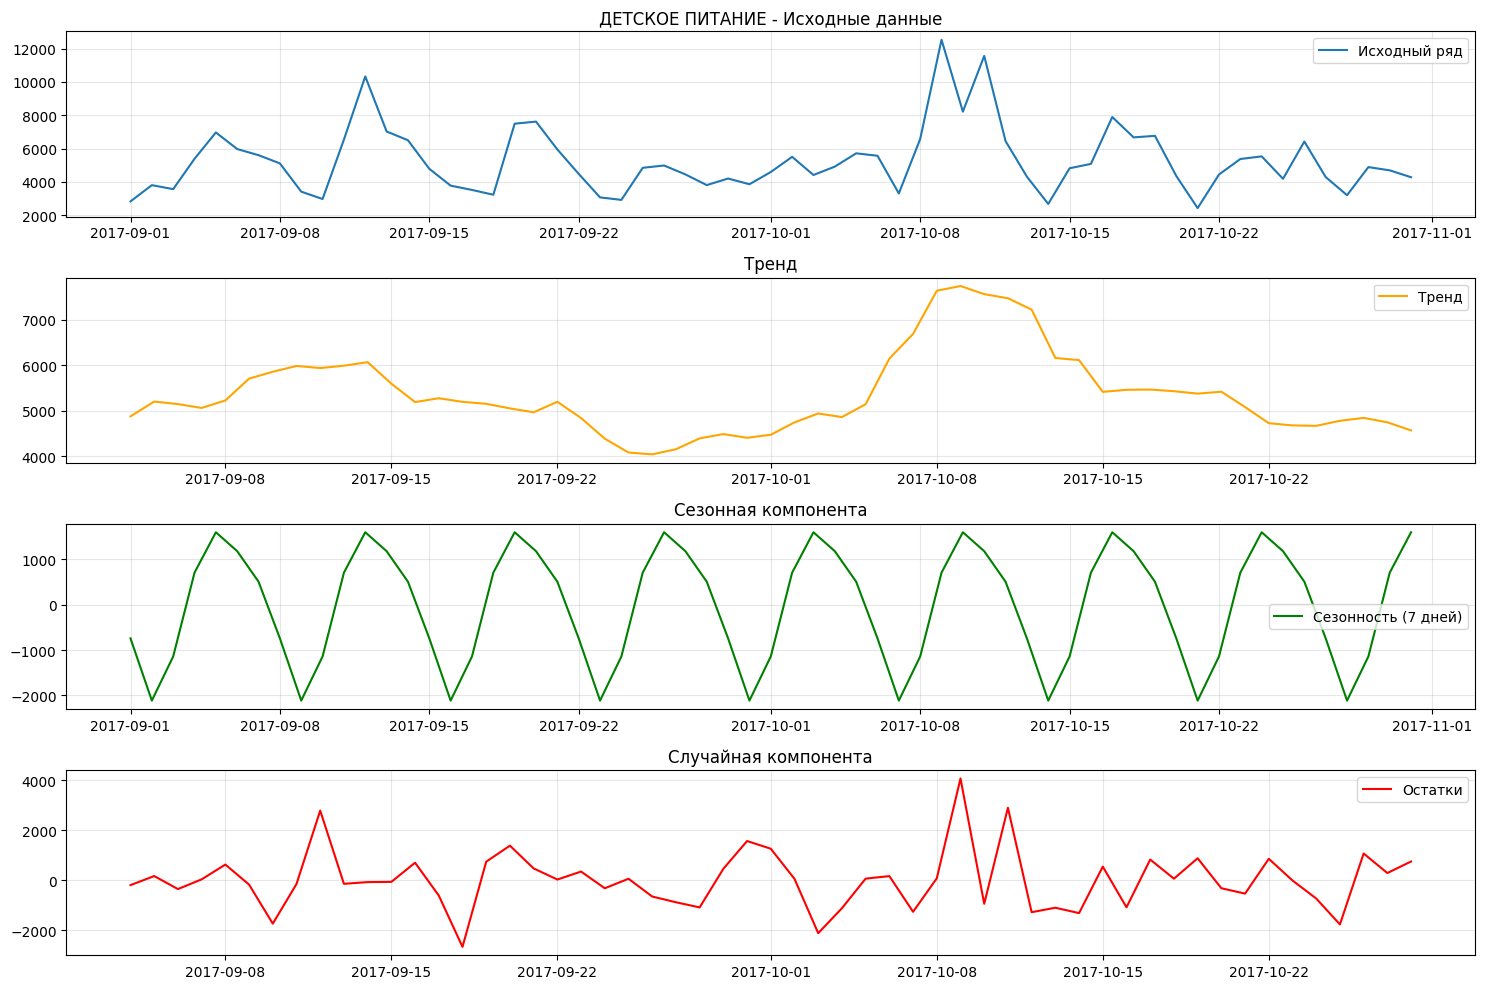

In [115]:
from statsmodels.tsa.seasonal import seasonal_decompose
import matplotlib.pyplot as plt

# Выберите одну группу для декомпозиции (например, самую популярную)
target_group = pivot.sum().idxmax()  # группа с максимальными продажами
print(f"Анализируем группу: {target_group}")

# Берем ряд для этой группы
series = pivot[target_group]

# Убеждаемся, что частота установлена (ежедневные данные)
series = series.asfreq('D').fillna(0)

# Декомпозиция (период = 7 для недельной сезонности)
decomposition = seasonal_decompose(series, model='additive', period=7)

# Визуализация
plt.figure(figsize=(15, 10))

plt.subplot(4, 1, 1)
plt.plot(series.index, series, label='Исходный ряд')
plt.title(f'{target_group} - Исходные данные')
plt.legend()
plt.grid(True, alpha=0.3)

plt.subplot(4, 1, 2)
plt.plot(series.index, decomposition.trend, label='Тренд', color='orange')
plt.title('Тренд')
plt.legend()
plt.grid(True, alpha=0.3)

plt.subplot(4, 1, 3)
plt.plot(series.index, decomposition.seasonal, label='Сезонность (7 дней)', color='green')
plt.title('Сезонная компонента')
plt.legend()
plt.grid(True, alpha=0.3)

plt.subplot(4, 1, 4)
plt.plot(series.index, decomposition.resid, label='Остатки', color='red')
plt.title('Случайная компонента')
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

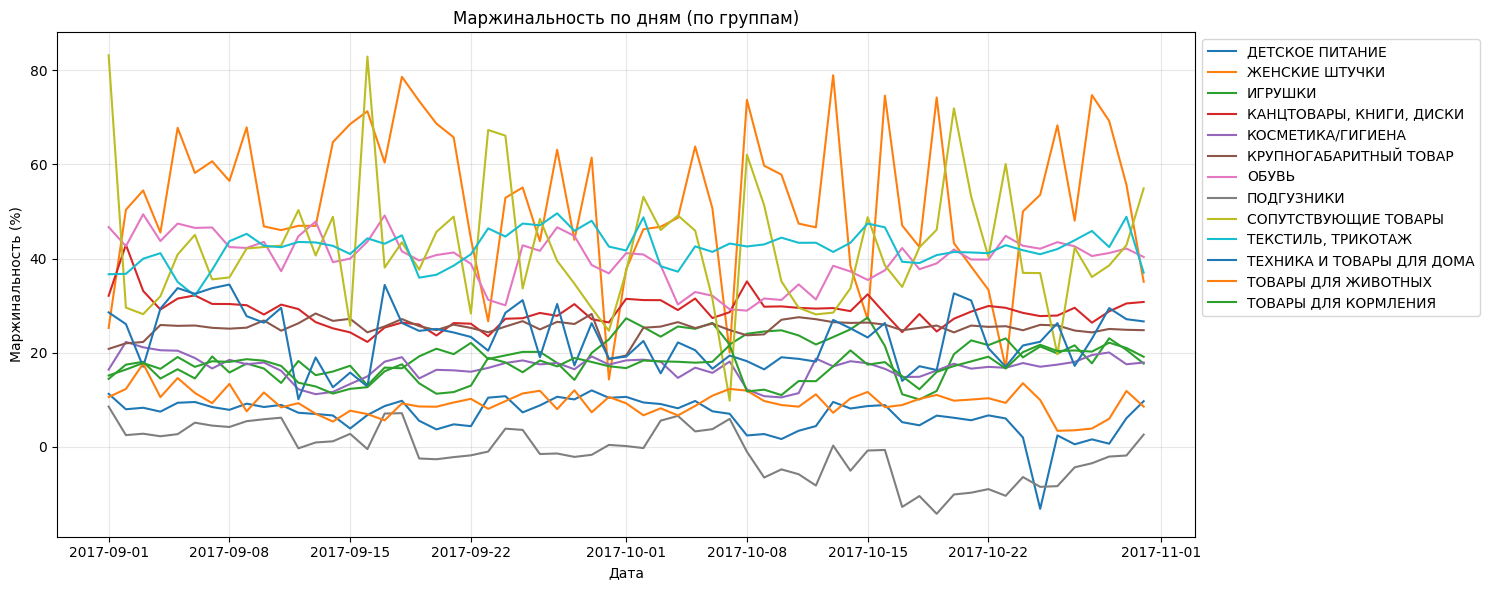

In [111]:
# Дневная маржинальность (с reset_index)
daily_margin = df_clean.groupby(['Date', 'Группа2']).agg({
    'СуммаСтроки': 'sum',
    'Маржа': 'sum'
}).reset_index()  # 

# Расчет маржинальности
daily_margin['Маржинальность_%'] = (daily_margin['Маржа'] / daily_margin['СуммаСтроки'] * 100).round(2)

# График (теперь можно обращаться к колонкам)
plt.figure(figsize=(15, 6))

# Для каждой группы свой график
for group in daily_margin['Группа2'].unique():
    group_data = daily_margin[daily_margin['Группа2'] == group]
    plt.plot(group_data['Date'], group_data['Маржинальность_%'], label=group, linewidth=1.5)

plt.title('Маржинальность по дням (по группам)')
plt.xlabel('Дата')
plt.ylabel('Маржинальность (%)')
plt.grid(True, alpha=0.3)
plt.legend(loc='upper left', bbox_to_anchor=(1, 1))
plt.tight_layout()
plt.show()

In [113]:
daily_margin.head(10)

,Date,Группа2,СуммаСтроки,Маржа,Маржинальность_%
0,2017-09-01,ДЕТСКОЕ ПИТАНИЕ,170763.0,19244.16,11.27
1,2017-09-01,ЖЕНСКИЕ ШТУЧКИ,211.0,53.31,25.27
2,2017-09-01,ИГРУШКИ,656245.0,94832.82,14.45
3,2017-09-01,"КАНЦТОВАРЫ, КНИГИ, ДИСКИ",69614.0,22344.51,32.10
4,2017-09-01,КОСМЕТИКА/ГИГИЕНА,177810.0,29190.17,16.42
5,2017-09-01,КРУПНОГАБАРИТНЫЙ ТОВАР,2237297.0,465879.65,20.82
6,2017-09-01,ОБУВЬ,323328.0,150938.27,46.68
7,2017-09-01,ПОДГУЗНИКИ,698884.0,59807.03,8.56
8,2017-09-01,СОПУТСТВУЮЩИЕ ТОВАРЫ,89.0,74.00,83.15
9,2017-09-01,"ТЕКСТИЛЬ, ТРИКОТАЖ",1276388.0,468003.16,36.67


In [86]:
df_clean['Отменено'] = df_clean['Отменено'].replace({ #бинарный признак можем не делать one-hot-encoding чтобы не увеличивать размерность лишний раз 
    'Да': 1.0,
    'Нет': 0.0
}).astype(float)

df_clean['ТипТовара'] = df_clean['ТипТовара'].replace({ #бинарный признак можем не делать one-hot-encoding чтобы не увеличивать размерность лишний раз 
    'МГТ': 1.0,
    'КГТ': 0.0
}).astype(float)

df_clean['ФормаОплаты'] = df_clean['ФормаОплаты'].replace({ #бинарный признак можем не делать one-hot-encoding чтобы не увеличивать размерность лишний раз 
    'Безналичная': 1.0,
    'Наличная': 0.0
}).astype(float)

C:\Users\ASUS\AppData\Local\Temp\ipykernel_15816\2487095165.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df_clean['Отменено'] = df_clean['Отменено'].replace({ #бинарный признак можем не делать one-hot-encoding чтобы не увеличивать размерность лишний раз
C:\Users\ASUS\AppData\Local\Temp\ipykernel_15816\2487095165.py:6: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df_clean['ТипТовара'] = df_clean['ТипТовара'].replace({ #бинарный признак можем не делать one-hot-encoding чтобы не увеличивать размерность лишний раз
C:\Users\ASU

In [35]:
# one-hot encoding
columns_to_encode = ['НовыйСтатус', 'МетодДоставки', 'Группа2', 'Тип', 'Статус']
df_clean = pd.concat([
    df_clean.drop(columns=columns_to_encode),
    pd.get_dummies(df_clean[columns_to_encode], dtype='float64')
], axis=1)

In [36]:
df_clean.head()

,Дата,ДатаДоставки,НомерЗаказаНаСайте,СуммаЗаказаНаСайте,СуммаДокумента,ФормаОплаты,Регион,Группа3,Группа4,Номенклатура,ТипТовара,Отменено,Количество,Цена,СуммаСтроки,ЦенаЗакупки,МесяцДатыЗаказа,ГодДатыЗаказа,Гео,Маржа,СуммаУслуг,СуммаДоставки,НомерСтроки,КоличествоПроданоКлиенту,ДатаЗаказаНаСайте,Телефон_new,ЭлектроннаяПочта_new,Клиент,ID_SKU,НовыйСтатус_В резерве,НовыйСтатус_Возврат из ПВЗ,НовыйСтатус_Доставлен,НовыйСтатус_К отгрузке,НовыйСтатус_Не обеспечен,НовыйСтатус_Отменен,НовыйСтатус_Отменяется,НовыйСтатус_Отправлен в ПВЗ,НовыйСтатус_Передан в Регион,НовыйСтатус_Принят в ПВЗ,НовыйСтатус_Расформирован ПВЗ,НовыйСтатус_Скомплектован Регион,НовыйСтатус_Частичный возврат,МетодДоставки_DPD,МетодДоставки_Pick point,МетодДоставки_Курьерская,МетодДоставки_Магазины,МетодДоставки_Самовывоз,МетодДоставки_Транспортная компания,Группа2_ДЕТСКОЕ ПИТАНИЕ,Группа2_ЖЕНСКИЕ ШТУЧКИ,Группа2_ИГРУШКИ,"Группа2_КАНЦТОВАРЫ, КНИГИ, ДИСКИ",Группа2_КОСМЕТИКА/ГИГИЕНА,Группа2_КРУПНОГАБАРИТНЫЙ ТОВАР,Группа2_ОБУВЬ,Группа2_ПОДГУЗНИКИ,Группа2_СОПУТСТВУЮЩИЕ ТОВАРЫ,"Группа2_ТЕКСТИЛЬ, ТРИКОТАЖ",Группа2_ТЕХНИКА И ТОВАРЫ ДЛЯ ДОМА,Группа2_ТОВАРЫ ДЛЯ ЖИВОТНЫХ,Группа2_ТОВАРЫ ДЛЯ КОРМЛЕНИЯ,Тип_ИГРУШКИ,Тип_ИНОЕ,Тип_КГТ,Тип_ОДЕЖДА,Тип_ППКП,Статус_В процессе,Статус_Возврат,Статус_Доставлен,Статус_Не определен,Статус_Отменен
1,01.09.2017 11:34,08.09.2017 0:00,5412440_TR,2614.0,150.0,0.0,Москва,ИГРУШКИ ДЛЯ ДЕВОЧЕК,наборы игровые,"PLAYSKOOL, ИГРУШКА Музыкальный замок Пони",1.0,1.0,1,1382.0,1382.0,1974.00,9,2 017,Москва,-592.00,150.0,150.0,2,1,31.08.2017 0:00,55574851-49485350505178,103117_gu12@mail.ru,Валентина,IDL00021467250,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
2,01.09.2017 11:34,08.09.2017 0:00,5412440_TR,2614.0,150.0,0.0,Москва,ИГРУШКИ ДЛЯ ДЕВОЧЕК,наборы игровые,"MY LITTLE PONY, НАБОР игровой Поезд Дружбы",1.0,1.0,1,843.0,843.0,1685.20,9,2 017,Москва,-842.20,150.0,150.0,1,1,31.08.2017 0:00,55574851-49485350505178,103117_gu12@mail.ru,Валентина,IDL00036071149,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
3,01.09.2017 11:34,08.09.2017 0:00,5412440_TR,2614.0,150.0,0.0,Москва,ИГРУШКИ ДЛЯ РАЗВИТИЯ МАЛЫШЕЙ,прочие игрушки для развития,"УМКА , ЧАСЫ Фиксики, с проекцией",1.0,1.0,1,239.0,239.0,154.98,9,2 017,Москва,84.02,150.0,150.0,3,1,31.08.2017 0:00,55574851-49485350505178,103117_gu12@mail.ru,Валентина,IDL00038944553,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
5,01.09.2017 0:05,11.09.2017 0:00,5412441_TR,4563.0,4563.0,1.0,Санкт-Петербург,КАНЦТОВАРЫ,предметы для рисования,ДОСКА с задвижками Первые навыки,1.0,0.0,1,2495.0,2495.0,1747.00,9,2 017,Регионы,748.00,99.0,99.0,1,0,31.08.2017 0:00,55575049-55525257485770,106117_ju17@mail.ru,Гость,ID9010014576553,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
6,01.09.2017 0:05,11.09.2017 0:00,5412441_TR,4563.0,4563.0,1.0,Санкт-Петербург,ИГРУШКИ ДЛЯ РАЗВИТИЯ МАЛЫШЕЙ,сортеры,"MELISSA&DOUG, ГАРАЖИ деревянные сортировщики",1.0,0.0,1,1969.0,1969.0,1519.00,9,2 017,Регионы,450.00,99.0,99.0,2,0,31.08.2017 0:00,55575049-55525257485770,106117_ju17@mail.ru,Гость,IDL00048845957,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0


In [37]:
# 1. Создаем маску с условиями для выкупов
#mask = (df_clean['Отменено'] == 'Нет') & \
       #(df_clean['Статус'] == 'Доставлен') & \
       #(df_clean['НовыйСтатус'] == 'Доставлен')

sold = df_clean[mask].groupby('Телефон_new')['КоличествоПроданоКлиенту'].sum()

sold_count = df_clean[mask].groupby('Телефон_new')['НомерЗаказаНаСайте'].nunique()

# Агрегация по клиентам (телефон как ID клиента)
df_clients = df_clean.groupby('Телефон_new').agg(
    # Заказы
    Количество_заказов=('НомерЗаказаНаСайте', 'nunique'),  # уникальных заказов
    Общее_количество_товаров=('Количество', 'sum'),
    #Среднее_количество_в_заказе=('Количество', 'mean'),
    
    # Деньги
    Общая_выручка=('СуммаСтроки', 'sum'),
    Средний_чек=('СуммаСтроки', 'mean'),
    #Минимальный_чек=('СуммаСтроки', 'min'),
    #Максимальный_чек=('СуммаСтроки', 'max'),
    
    # Товары
    #Уникальных_SKU=('ID_SKU', 'nunique'),
    #Всего_позиций=('ID_SKU', 'count'),  # количество строк
    
    # Маржа
    Общая_маржа=('Маржа', 'sum'),
    Средняя_маржа_на_строку=('Маржа', 'mean'),
    
    # Продажи
    Количество_продано=('КоличествоПроданоКлиенту', 'sum'),
    
    # Email (на всякий случай)
    #Количество_email=('ЭлектроннаяПочта_new', 'nunique'),
    #Основной_email=('ЭлектроннаяПочта_new', 'first')
).reset_index()

# Добавляем расчетные метрики
df_clients['Маржинальность_%'] = (df_clients['Общая_маржа'] / df_clients['Общая_выручка'] * 100).round(2)
df_clients['Товаров_на_заказ'] = (df_clients['Общее_количество_товаров'] / df_clients['Количество_заказов']).round(2)
#df_clients['Строк_на_заказ'] = (df_clients['Всего_позиций'] / df_clients['Количество_заказов']).round(2)

# 4. Добавляем количество выкупов
df_clients['количество_выкупов_товаров'] = df_clients['Телефон_new'].map(sold).fillna(0)
df_clients['количество_выкупов_заказов'] = df_clients['Телефон_new'].map(sold_count).fillna(0)

# 5. Добавляем процент выкупа
df_clients['процент_выкупа_%'] = (df_clients['количество_выкупов_товаров'] / 
                                  df_clients['Количество_продано'] * 100).round(2)

df_clients['Выручка_выкуп'] = ((df_clients['Общая_выручка'] * df_clients['процент_выкупа_%'])/100).round(2)

# Сортируем по активности
df_clients = df_clients.sort_values('Количество_заказов', ascending=False)

df_clients.head(10)

,Телефон_new,Количество_заказов,Общее_количество_товаров,Общая_выручка,Средний_чек,Общая_маржа,Средняя_маржа_на_строку,Количество_продано,Маржинальность_%,Товаров_на_заказ,количество_выкупов_товаров,количество_выкупов_заказов,процент_выкупа_%,Выручка_выкуп
29490,55574949-49545651525076,59,169,68432.0,417.268293,15908.67,97.004085,113,23.25,2.86,71.0,26.0,62.83,42995.83
82464,55575054-53555154495074,52,71,192447.0,2710.521127,23816.61,335.445211,70,12.38,1.37,67.0,50.0,95.71,184191.02
20774,55574856-49505152484873,46,230,129508.0,719.488889,40538.09,225.211611,133,31.30,5.00,1.0,1.0,0.75,971.31
76854,55575054-50505252535072,41,60,156114.0,2601.900000,18566.76,309.446000,58,11.89,1.46,56.0,39.0,96.55,150728.07
86725,55575054-57494849545177,32,95,97224.0,1092.404494,12979.13,145.832921,62,13.35,2.97,29.0,13.0,46.77,45471.66
74926,55575054-49505057545771,31,95,57685.0,721.062500,15962.06,199.525750,82,27.67,3.06,42.0,8.0,51.22,29546.26
2054,55574851-48484953515776,30,166,49166.0,438.982143,13449.54,120.085179,102,27.36,5.53,93.0,12.0,91.18,44829.56
58540,55574957-55575356514873,30,161,55462.0,362.496732,11975.22,78.269412,143,21.59,5.37,63.0,12.0,44.06,24436.56
123322,55575655-50505253555077,28,217,74583.0,351.806604,21679.27,102.260708,89,29.07,7.75,0.0,0.0,0.00,0.00
72457,55575053-54505550565678,27,147,143522.0,1121.265625,18632.39,145.565547,114,12.98,5.44,51.0,14.0,44.74,64211.74


In [38]:
# Создаем список колонок с one-hot encoding групп товаров
group_columns = [col for col in df_clean.columns if col.startswith('Группа2_')]

# Суммируем по каждому клиенту
client_groups = df_clean.groupby('Телефон_new')[group_columns].sum().reset_index()

# Объединяем с основным датафреймом клиентов
df_clients = df_clients.merge(client_groups, on='Телефон_new', how='left')

In [39]:
df_clients.head(10)

,Телефон_new,Количество_заказов,Общее_количество_товаров,Общая_выручка,Средний_чек,Общая_маржа,Средняя_маржа_на_строку,Количество_продано,Маржинальность_%,Товаров_на_заказ,количество_выкупов_товаров,количество_выкупов_заказов,процент_выкупа_%,Выручка_выкуп,Группа2_ДЕТСКОЕ ПИТАНИЕ,Группа2_ЖЕНСКИЕ ШТУЧКИ,Группа2_ИГРУШКИ,"Группа2_КАНЦТОВАРЫ, КНИГИ, ДИСКИ",Группа2_КОСМЕТИКА/ГИГИЕНА,Группа2_КРУПНОГАБАРИТНЫЙ ТОВАР,Группа2_ОБУВЬ,Группа2_ПОДГУЗНИКИ,Группа2_СОПУТСТВУЮЩИЕ ТОВАРЫ,"Группа2_ТЕКСТИЛЬ, ТРИКОТАЖ",Группа2_ТЕХНИКА И ТОВАРЫ ДЛЯ ДОМА,Группа2_ТОВАРЫ ДЛЯ ЖИВОТНЫХ,Группа2_ТОВАРЫ ДЛЯ КОРМЛЕНИЯ
0,55574949-49545651525076,59,169,68432.0,417.268293,15908.67,97.004085,113,23.25,2.86,71.0,26.0,62.83,42995.83,0.0,2.0,1.0,1.0,7.0,0.0,51.0,7.0,0.0,95.0,0.0,0.0,0.0
1,55575054-53555154495074,52,71,192447.0,2710.521127,23816.61,335.445211,70,12.38,1.37,67.0,50.0,95.71,184191.02,0.0,0.0,0.0,0.0,0.0,0.0,2.0,0.0,0.0,68.0,0.0,0.0,1.0
2,55574856-49505152484873,46,230,129508.0,719.488889,40538.09,225.211611,133,31.30,5.00,1.0,1.0,0.75,971.31,38.0,2.0,30.0,14.0,8.0,0.0,25.0,2.0,3.0,55.0,0.0,0.0,3.0
3,55575054-50505252535072,41,60,156114.0,2601.900000,18566.76,309.446000,58,11.89,1.46,56.0,39.0,96.55,150728.07,0.0,0.0,0.0,0.0,0.0,0.0,3.0,0.0,0.0,57.0,0.0,0.0,0.0
4,55575054-57494849545177,32,95,97224.0,1092.404494,12979.13,145.832921,62,13.35,2.97,29.0,13.0,46.77,45471.66,0.0,0.0,15.0,3.0,0.0,4.0,16.0,0.0,2.0,48.0,0.0,0.0,1.0
5,55575054-49505057545771,31,95,57685.0,721.062500,15962.06,199.525750,82,27.67,3.06,42.0,8.0,51.22,29546.26,13.0,2.0,7.0,7.0,8.0,4.0,10.0,2.0,5.0,12.0,0.0,2.0,8.0
6,55574851-48484953515776,30,166,49166.0,438.982143,13449.54,120.085179,102,27.36,5.53,93.0,12.0,91.18,44829.56,10.0,0.0,18.0,0.0,2.0,0.0,0.0,3.0,0.0,53.0,1.0,12.0,13.0
7,55574957-55575356514873,30,161,55462.0,362.496732,11975.22,78.269412,143,21.59,5.37,63.0,12.0,44.06,24436.56,0.0,0.0,39.0,3.0,4.0,0.0,9.0,3.0,0.0,94.0,0.0,0.0,1.0
8,55575655-50505253555077,28,217,74583.0,351.806604,21679.27,102.260708,89,29.07,7.75,0.0,0.0,0.00,0.00,0.0,3.0,14.0,3.0,42.0,1.0,30.0,10.0,0.0,103.0,5.0,0.0,1.0
9,55575053-54505550565678,27,147,143522.0,1121.265625,18632.39,145.565547,114,12.98,5.44,51.0,14.0,44.74,64211.74,0.0,0.0,2.0,0.0,0.0,1.0,27.0,0.0,0.0,96.0,2.0,0.0,0.0


In [40]:
customer_phone = df_clients['Телефон_new'].copy()

df_clients = df_clients.drop(columns=['Телефон_new'])

df_clients = df_clients.fillna(0)

In [41]:
df_clients.head(10)

,Количество_заказов,Общее_количество_товаров,Общая_выручка,Средний_чек,Общая_маржа,Средняя_маржа_на_строку,Количество_продано,Маржинальность_%,Товаров_на_заказ,количество_выкупов_товаров,количество_выкупов_заказов,процент_выкупа_%,Выручка_выкуп,Группа2_ДЕТСКОЕ ПИТАНИЕ,Группа2_ЖЕНСКИЕ ШТУЧКИ,Группа2_ИГРУШКИ,"Группа2_КАНЦТОВАРЫ, КНИГИ, ДИСКИ",Группа2_КОСМЕТИКА/ГИГИЕНА,Группа2_КРУПНОГАБАРИТНЫЙ ТОВАР,Группа2_ОБУВЬ,Группа2_ПОДГУЗНИКИ,Группа2_СОПУТСТВУЮЩИЕ ТОВАРЫ,"Группа2_ТЕКСТИЛЬ, ТРИКОТАЖ",Группа2_ТЕХНИКА И ТОВАРЫ ДЛЯ ДОМА,Группа2_ТОВАРЫ ДЛЯ ЖИВОТНЫХ,Группа2_ТОВАРЫ ДЛЯ КОРМЛЕНИЯ
0,59,169,68432.0,417.268293,15908.67,97.004085,113,23.25,2.86,71.0,26.0,62.83,42995.83,0.0,2.0,1.0,1.0,7.0,0.0,51.0,7.0,0.0,95.0,0.0,0.0,0.0
1,52,71,192447.0,2710.521127,23816.61,335.445211,70,12.38,1.37,67.0,50.0,95.71,184191.02,0.0,0.0,0.0,0.0,0.0,0.0,2.0,0.0,0.0,68.0,0.0,0.0,1.0
2,46,230,129508.0,719.488889,40538.09,225.211611,133,31.30,5.00,1.0,1.0,0.75,971.31,38.0,2.0,30.0,14.0,8.0,0.0,25.0,2.0,3.0,55.0,0.0,0.0,3.0
3,41,60,156114.0,2601.900000,18566.76,309.446000,58,11.89,1.46,56.0,39.0,96.55,150728.07,0.0,0.0,0.0,0.0,0.0,0.0,3.0,0.0,0.0,57.0,0.0,0.0,0.0
4,32,95,97224.0,1092.404494,12979.13,145.832921,62,13.35,2.97,29.0,13.0,46.77,45471.66,0.0,0.0,15.0,3.0,0.0,4.0,16.0,0.0,2.0,48.0,0.0,0.0,1.0
5,31,95,57685.0,721.062500,15962.06,199.525750,82,27.67,3.06,42.0,8.0,51.22,29546.26,13.0,2.0,7.0,7.0,8.0,4.0,10.0,2.0,5.0,12.0,0.0,2.0,8.0
6,30,166,49166.0,438.982143,13449.54,120.085179,102,27.36,5.53,93.0,12.0,91.18,44829.56,10.0,0.0,18.0,0.0,2.0,0.0,0.0,3.0,0.0,53.0,1.0,12.0,13.0
7,30,161,55462.0,362.496732,11975.22,78.269412,143,21.59,5.37,63.0,12.0,44.06,24436.56,0.0,0.0,39.0,3.0,4.0,0.0,9.0,3.0,0.0,94.0,0.0,0.0,1.0
8,28,217,74583.0,351.806604,21679.27,102.260708,89,29.07,7.75,0.0,0.0,0.00,0.00,0.0,3.0,14.0,3.0,42.0,1.0,30.0,10.0,0.0,103.0,5.0,0.0,1.0
9,27,147,143522.0,1121.265625,18632.39,145.565547,114,12.98,5.44,51.0,14.0,44.74,64211.74,0.0,0.0,2.0,0.0,0.0,1.0,27.0,0.0,0.0,96.0,2.0,0.0,0.0


In [76]:
df_clients.shape[1]

24

In [42]:
def columnValues(df_clients):

    total_rows = len(df_clients)

    unique_count = df_clients.nunique()
    zeros_count = (df_clients == 0).sum(axis=0)
    nan_count = df_clients.isna().sum()

    # Рассчитываем проценты
    unique_percent = round((unique_count / total_rows * 100), 1)
    zeros_percent = round((zeros_count / total_rows * 100), 1)
    nan_percent = round((nan_count / total_rows * 100), 1)
    data_types = df_clients.dtypes

    # Формируем строку: каждая метрика сразу со своим процентом
    row = [unique_count, f"{unique_percent}%",
           zeros_count, f"{zeros_percent}%",
           nan_count, f"{nan_percent}%",
           data_types]
    return row

data = []
for column in df_clients.columns:
    data.append([column] + columnValues(df_clients[column]))

print(tabulate(data, headers=['Column', 'Unique', '% of_Unique', 'Zeros', '% of_Zeros', 'NaNs', '% of_NaNs', 'dtype'],
               tablefmt='orgtbl'))

| Column                            |   Unique | % of_Unique   |   Zeros | % of_Zeros   |   NaNs | % of_NaNs   | dtype   |
|-----------------------------------+----------+---------------+---------+--------------+--------+-------------+---------|
| Количество_заказов                |       35 | 0.0%          |       0 | 0.0%         |      0 | 0.0%        | int64   |
| Общее_количество_товаров          |      325 | 0.3%          |       0 | 0.0%         |      0 | 0.0%        | int64   |
| Общая_выручка                     |    18445 | 14.6%         |       0 | 0.0%         |      0 | 0.0%        | float64 |
| Средний_чек                       |    38706 | 30.7%         |       0 | 0.0%         |      0 | 0.0%        | float64 |
| Общая_маржа                       |    71776 | 57.0%         |      11 | 0.0%         |      0 | 0.0%        | float64 |
| Средняя_маржа_на_строку           |    77012 | 61.1%         |      11 | 0.0%         |      0 | 0.0%        | float64 |
| Количество_про

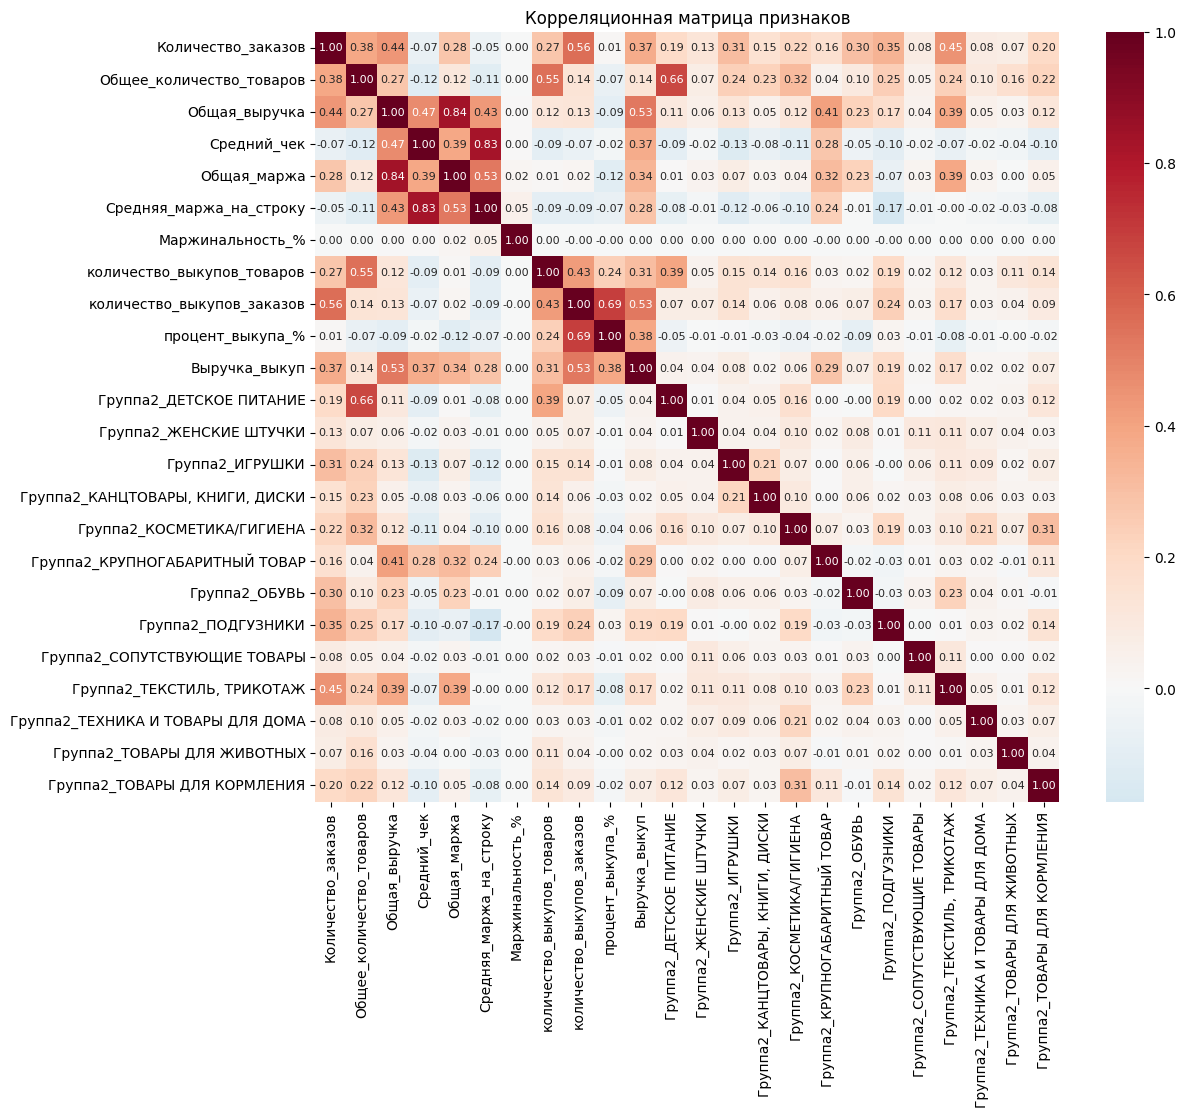


Пары с корреляцией > 0.75:
Общая_выручка — Общая_маржа: 0.840
Средний_чек — Средняя_маржа_на_строку: 0.828


In [58]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# Смотрим корреляционную матрицу
corr_matrix = df_clients.corr()

# Визуализируем корреляции
plt.figure(figsize=(12, 10))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='RdBu_r', annot_kws={'size': 8}, center=0)
plt.title('Корреляционная матрица признаков')
plt.show()

# Находим пары с высокой корреляцией (> 0.75)
high_corr_pairs = []
threshold = 0.75

for i in range(len(corr_matrix.columns)):
    for j in range(i+1, len(corr_matrix.columns)):
        if abs(corr_matrix.iloc[i, j]) > threshold:
            high_corr_pairs.append({
                'признак_1': corr_matrix.columns[i],
                'признак_2': corr_matrix.columns[j],
                'корреляция': corr_matrix.iloc[i, j]
            })

print(f"\nПары с корреляцией > {threshold}:")
for pair in high_corr_pairs:
    print(f"{pair['признак_1']} — {pair['признак_2']}: {pair['корреляция']:.3f}")

In [ ]:
df_clients = df_clients.drop(columns=['Количество_продано'])

df_clients = df_clients.drop(columns=['Товаров_на_заказ'])


In [46]:
print(df_clients.dtypes.value_counts())
print(f"Все колонки: {df_clients.columns.tolist()}")
print(f"Форма: {df_clients.shape}") 

float64    22
int64       2
Name: count, dtype: int64
Все колонки: ['Количество_заказов', 'Общее_количество_товаров', 'Общая_выручка', 'Средний_чек', 'Общая_маржа', 'Средняя_маржа_на_строку', 'Маржинальность_%', 'количество_выкупов_товаров', 'количество_выкупов_заказов', 'процент_выкупа_%', 'Выручка_выкуп', 'Группа2_ДЕТСКОЕ ПИТАНИЕ', 'Группа2_ЖЕНСКИЕ ШТУЧКИ', 'Группа2_ИГРУШКИ', 'Группа2_КАНЦТОВАРЫ, КНИГИ, ДИСКИ', 'Группа2_КОСМЕТИКА/ГИГИЕНА', 'Группа2_КРУПНОГАБАРИТНЫЙ ТОВАР', 'Группа2_ОБУВЬ', 'Группа2_ПОДГУЗНИКИ', 'Группа2_СОПУТСТВУЮЩИЕ ТОВАРЫ', 'Группа2_ТЕКСТИЛЬ, ТРИКОТАЖ', 'Группа2_ТЕХНИКА И ТОВАРЫ ДЛЯ ДОМА', 'Группа2_ТОВАРЫ ДЛЯ ЖИВОТНЫХ', 'Группа2_ТОВАРЫ ДЛЯ КОРМЛЕНИЯ']
Форма: (125996, 24)


In [78]:
df_clean.head()

,Дата,ДатаДоставки,НомерЗаказаНаСайте,СуммаЗаказаНаСайте,СуммаДокумента,ФормаОплаты,Регион,Группа3,Группа4,Номенклатура,ТипТовара,Отменено,Количество,Цена,СуммаСтроки,ЦенаЗакупки,МесяцДатыЗаказа,ГодДатыЗаказа,Гео,Маржа,СуммаУслуг,СуммаДоставки,НомерСтроки,КоличествоПроданоКлиенту,ДатаЗаказаНаСайте,Телефон_new,ЭлектроннаяПочта_new,Клиент,ID_SKU,НовыйСтатус_В резерве,НовыйСтатус_Возврат из ПВЗ,НовыйСтатус_Доставлен,НовыйСтатус_К отгрузке,НовыйСтатус_Не обеспечен,НовыйСтатус_Отменен,НовыйСтатус_Отменяется,НовыйСтатус_Отправлен в ПВЗ,НовыйСтатус_Передан в Регион,НовыйСтатус_Принят в ПВЗ,НовыйСтатус_Расформирован ПВЗ,НовыйСтатус_Скомплектован Регион,НовыйСтатус_Частичный возврат,МетодДоставки_DPD,МетодДоставки_Pick point,МетодДоставки_Курьерская,МетодДоставки_Магазины,МетодДоставки_Самовывоз,МетодДоставки_Транспортная компания,Группа2_ДЕТСКОЕ ПИТАНИЕ,Группа2_ЖЕНСКИЕ ШТУЧКИ,Группа2_ИГРУШКИ,"Группа2_КАНЦТОВАРЫ, КНИГИ, ДИСКИ",Группа2_КОСМЕТИКА/ГИГИЕНА,Группа2_КРУПНОГАБАРИТНЫЙ ТОВАР,Группа2_ОБУВЬ,Группа2_ПОДГУЗНИКИ,Группа2_СОПУТСТВУЮЩИЕ ТОВАРЫ,"Группа2_ТЕКСТИЛЬ, ТРИКОТАЖ",Группа2_ТЕХНИКА И ТОВАРЫ ДЛЯ ДОМА,Группа2_ТОВАРЫ ДЛЯ ЖИВОТНЫХ,Группа2_ТОВАРЫ ДЛЯ КОРМЛЕНИЯ,Тип_ИГРУШКИ,Тип_ИНОЕ,Тип_КГТ,Тип_ОДЕЖДА,Тип_ППКП,Статус_В процессе,Статус_Возврат,Статус_Доставлен,Статус_Не определен,Статус_Отменен
1,01.09.2017 11:34,08.09.2017 0:00,5412440_TR,2614.0,150.0,0.0,Москва,ИГРУШКИ ДЛЯ ДЕВОЧЕК,наборы игровые,"PLAYSKOOL, ИГРУШКА Музыкальный замок Пони",1.0,1.0,1,1382.0,1382.0,1974.00,9,2 017,Москва,-592.00,150.0,150.0,2,1,31.08.2017 0:00,55574851-49485350505178,103117_gu12@mail.ru,Валентина,IDL00021467250,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
2,01.09.2017 11:34,08.09.2017 0:00,5412440_TR,2614.0,150.0,0.0,Москва,ИГРУШКИ ДЛЯ ДЕВОЧЕК,наборы игровые,"MY LITTLE PONY, НАБОР игровой Поезд Дружбы",1.0,1.0,1,843.0,843.0,1685.20,9,2 017,Москва,-842.20,150.0,150.0,1,1,31.08.2017 0:00,55574851-49485350505178,103117_gu12@mail.ru,Валентина,IDL00036071149,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
3,01.09.2017 11:34,08.09.2017 0:00,5412440_TR,2614.0,150.0,0.0,Москва,ИГРУШКИ ДЛЯ РАЗВИТИЯ МАЛЫШЕЙ,прочие игрушки для развития,"УМКА , ЧАСЫ Фиксики, с проекцией",1.0,1.0,1,239.0,239.0,154.98,9,2 017,Москва,84.02,150.0,150.0,3,1,31.08.2017 0:00,55574851-49485350505178,103117_gu12@mail.ru,Валентина,IDL00038944553,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
5,01.09.2017 0:05,11.09.2017 0:00,5412441_TR,4563.0,4563.0,1.0,Санкт-Петербург,КАНЦТОВАРЫ,предметы для рисования,ДОСКА с задвижками Первые навыки,1.0,0.0,1,2495.0,2495.0,1747.00,9,2 017,Регионы,748.00,99.0,99.0,1,0,31.08.2017 0:00,55575049-55525257485770,106117_ju17@mail.ru,Гость,ID9010014576553,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
6,01.09.2017 0:05,11.09.2017 0:00,5412441_TR,4563.0,4563.0,1.0,Санкт-Петербург,ИГРУШКИ ДЛЯ РАЗВИТИЯ МАЛЫШЕЙ,сортеры,"MELISSA&DOUG, ГАРАЖИ деревянные сортировщики",1.0,0.0,1,1969.0,1969.0,1519.00,9,2 017,Регионы,450.00,99.0,99.0,2,0,31.08.2017 0:00,55575049-55525257485770,106117_ju17@mail.ru,Гость,IDL00048845957,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0


In [47]:
from sklearn.ensemble import IsolationForest
from sklearn.svm import OneClassSVM
from sklearn.neighbors import LocalOutlierFactor
from sklearn import preprocessing

In [48]:
from sklearn.cluster import KMeans #DBSCAN, AgglomerativeClustering, MeanShift, MiniBatchKMeans, OPTICS
from sklearn.metrics import silhouette_score
from scipy.spatial.distance import cdist

In [49]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

# 1. Масштабируем данные (ОБЯЗАТЕЛЬНЫЙ ШАГ!)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df_clients) 

# 2. Теперь применяем PCA к масштабированным данным
pca = PCA(n_components=0.90)  # или фиксированное число компонент
X_pca = pca.fit_transform(X_scaled)

print(f"До масштабирования: {df_clients.std(axis=0).mean():.2f}")  # большой разброс
print(f"После масштабирования: {X_scaled.std(axis=0).mean():.2f}")  # должно быть ~1
print(f"Объясненная дисперсия: {pca.explained_variance_ratio_.cumsum()[-1]:.2%}")

До масштабирования: 1031.83
После масштабирования: 1.00
Объясненная дисперсия: 90.33%


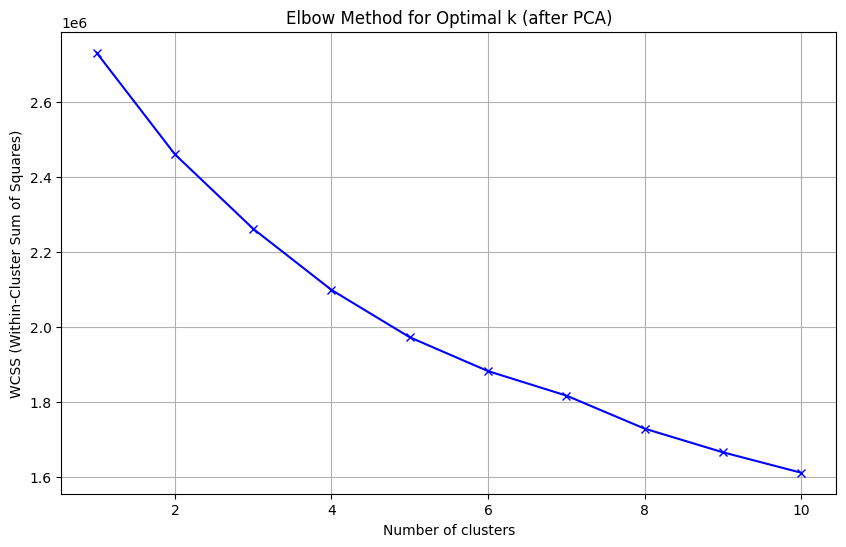

In [57]:
# k means determine k
distortions = []
K = range(1, 11)

for k in K:
    kmeanModel = KMeans(n_clusters=k, max_iter=300, n_init=10, random_state=0)
    kmeanModel.fit(X_pca)
    distortions.append(kmeanModel.inertia_) 

# Визуализация
plt.figure(figsize=(10, 6))
plt.plot(K, distortions, 'bx-')
plt.xlabel('Number of clusters')
plt.ylabel('WCSS (Within-Cluster Sum of Squares)')
plt.title('Elbow Method for Optimal k (after PCA)')
plt.grid(True)
plt.show()

Silhouette Score (выборка 10000):
k=2: 0.5939
k=3: 0.4863
k=4: 0.2414
k=5: 0.2414
k=6: 0.2453
k=7: 0.2493
k=8: 0.2485
k=9: 0.2572
k=10: 0.2558

 Оптимальное k = 2


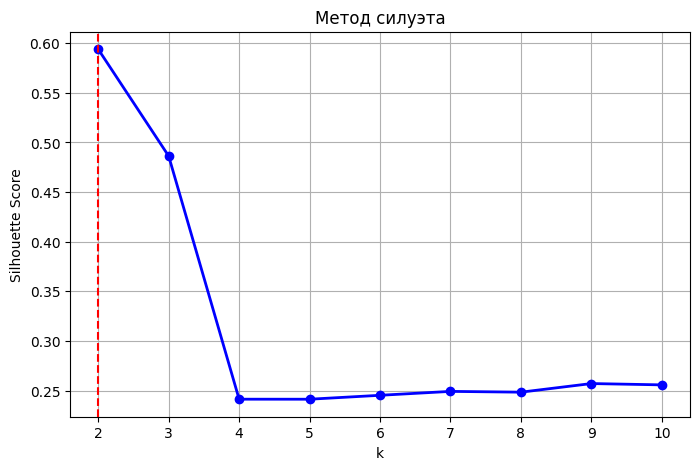

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

# Выборка 10000 точек (обязательно для вашего объема!)
sample_size = 10000
indices = np.random.choice(len(X_pca), sample_size, replace=False)
X_sample = X_pca[indices]

# Расчет силуэта
silhouette_scores = []
K = range(2, 11)

print("Silhouette Score (выборка 10000):")
for k in K:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(X_pca)
    score = silhouette_score(X_sample, labels[indices])
    silhouette_scores.append(score)
    print(f"k={k}: {score:.4f}")

# Оптимальное k
optimal_k = K[np.argmax(silhouette_scores)]
print(f"\n Оптимальное k = {optimal_k}")

# График
plt.figure(figsize=(8, 5))
plt.plot(K, silhouette_scores, 'bo-', linewidth=2)
plt.axvline(x=optimal_k, color='r', linestyle='--')
plt.xlabel('k')
plt.ylabel('Silhouette Score')
plt.title('Метод силуэта')
plt.grid(True)
plt.show()

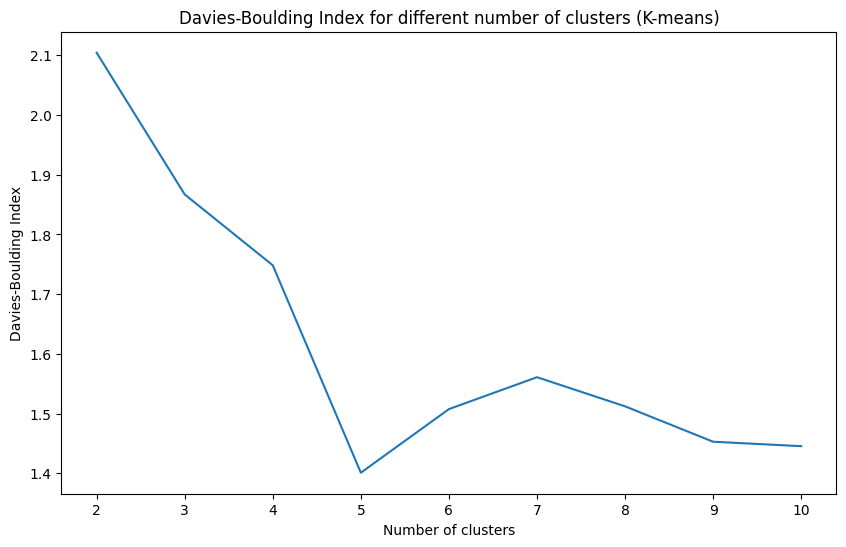

In [59]:
from sklearn.metrics import davies_bouldin_score
results_db_kmeans = {}
for i in range(2, 11):

    kmeans = KMeans(n_clusters = i, max_iter=500, n_init=20, random_state=7)
    labels = kmeans.fit_predict(X_pca)

    db_index = davies_bouldin_score(X_pca, labels)
    results_db_kmeans.update({i: db_index})

plt.figure(figsize=(10, 6))

plt.plot(list(results_db_kmeans.keys()), list(results_db_kmeans.values()))

plt.xticks(np.arange(2, 11, step = 1))
plt.xlabel('Number of clusters')
plt.ylabel('Davies-Boulding Index')
plt.title('Davies-Boulding Index for different number of clusters (K-means)')
plt.show()

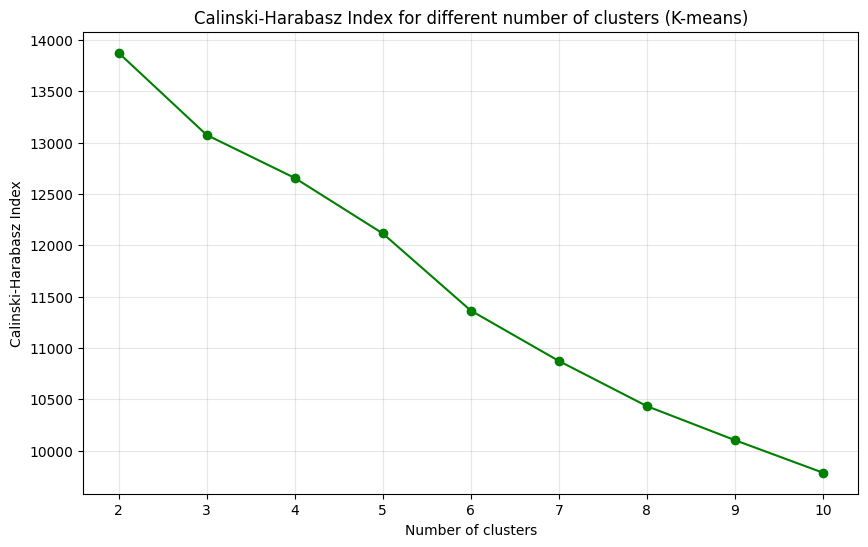

Оптимальное k = 2


In [60]:
from sklearn.metrics import calinski_harabasz_score
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
import numpy as np

results_ch_kmeans = {}
for i in range(2, 11):
    kmeans = KMeans(n_clusters=i, max_iter=500, n_init=20, random_state=7)
    labels = kmeans.fit_predict(X_pca)
    
    ch_index = calinski_harabasz_score(X_pca, labels)
    results_ch_kmeans.update({i: ch_index})

plt.figure(figsize=(10, 6))
plt.plot(list(results_ch_kmeans.keys()), list(results_ch_kmeans.values()), 'go-')
plt.xticks(np.arange(2, 11, step=1))
plt.xlabel('Number of clusters')
plt.ylabel('Calinski-Harabasz Index')
plt.title('Calinski-Harabasz Index for different number of clusters (K-means)')
plt.grid(True, alpha=0.3)
plt.show()

# Находим оптимальное k (максимум)
optimal_k = max(results_ch_kmeans, key=results_ch_kmeans.get)
print(f"Оптимальное k = {optimal_k}")

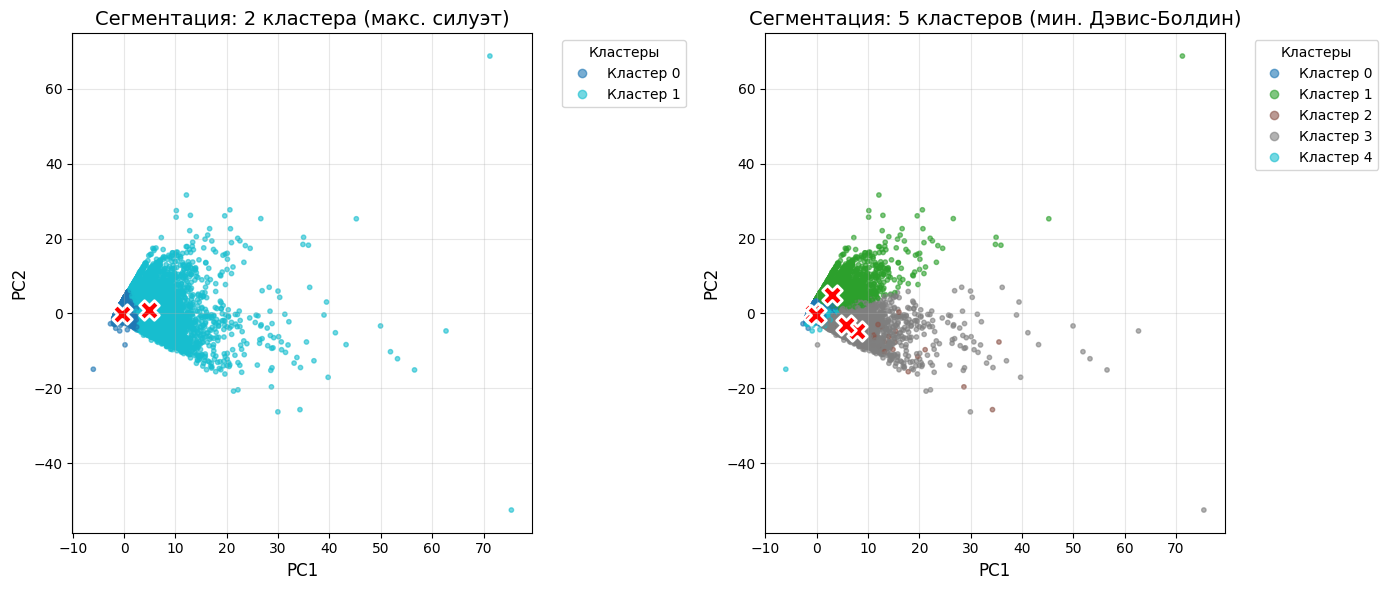

In [100]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans

# Допустим, у вас есть:
best_k = 2      # оптимальное по силуэту
best_k_2 = 5    # оптимальное по Дэвису-Болдину

# Кластеризация
kmeans_best = KMeans(n_clusters=best_k, random_state=42)
labels_best = kmeans_best.fit_predict(X_scaled)

kmeans_min = KMeans(n_clusters=best_k_2, random_state=42)
labels_min = kmeans_min.fit_predict(X_scaled)

# PCA для визуализации
X_pca = PCA(n_components=2).fit_transform(X_scaled)

# Визуализация
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# График 1: Оптимальное k (2)
scatter1 = axes[0].scatter(X_pca[:, 0], X_pca[:, 1], 
                          c=labels_best, cmap='tab10', alpha=0.6, s=10)

centers_best = np.array([X_pca[labels_best == i].mean(axis=0) 
                         for i in range(best_k)])
axes[0].scatter(centers_best[:, 0], centers_best[:, 1], 
                c='red', s=200, marker='X', edgecolors='white', linewidth=2)

axes[0].set_xlabel('PC1', fontsize=12)
axes[0].set_ylabel('PC2', fontsize=12)
axes[0].set_title(f'Сегментация: {best_k} кластера (макс. силуэт)', fontsize=14)
axes[0].grid(True, alpha=0.3)

# Легенда для первого графика
handles1, labels1 = scatter1.legend_elements()
axes[0].legend(handles1, [f'Кластер {i}' for i in range(best_k)], 
               title="Кластеры", bbox_to_anchor=(1.05, 1), loc='upper left')

# График 2: Минимальное по Дэвису-Болдину (5)
scatter2 = axes[1].scatter(X_pca[:, 0], X_pca[:, 1], 
                          c=labels_min, cmap='tab10', alpha=0.6, s=10)

centers_min = np.array([X_pca[labels_min == i].mean(axis=0) 
                        for i in range(best_k_2)])
axes[1].scatter(centers_min[:, 0], centers_min[:, 1], 
                c='red', s=200, marker='X', edgecolors='white', linewidth=2)

axes[1].set_xlabel('PC1', fontsize=12)
axes[1].set_ylabel('PC2', fontsize=12)
axes[1].set_title(f'Сегментация: {best_k_2} кластеров (мин. Дэвис-Болдин)', fontsize=14)
axes[1].grid(True, alpha=0.3)

# Легенда для второго графика
handles2, labels2 = scatter2.legend_elements()
axes[1].legend(handles2, [f'Кластер {i}' for i in range(best_k_2)], 
               title="Кластеры", bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout()
plt.show()

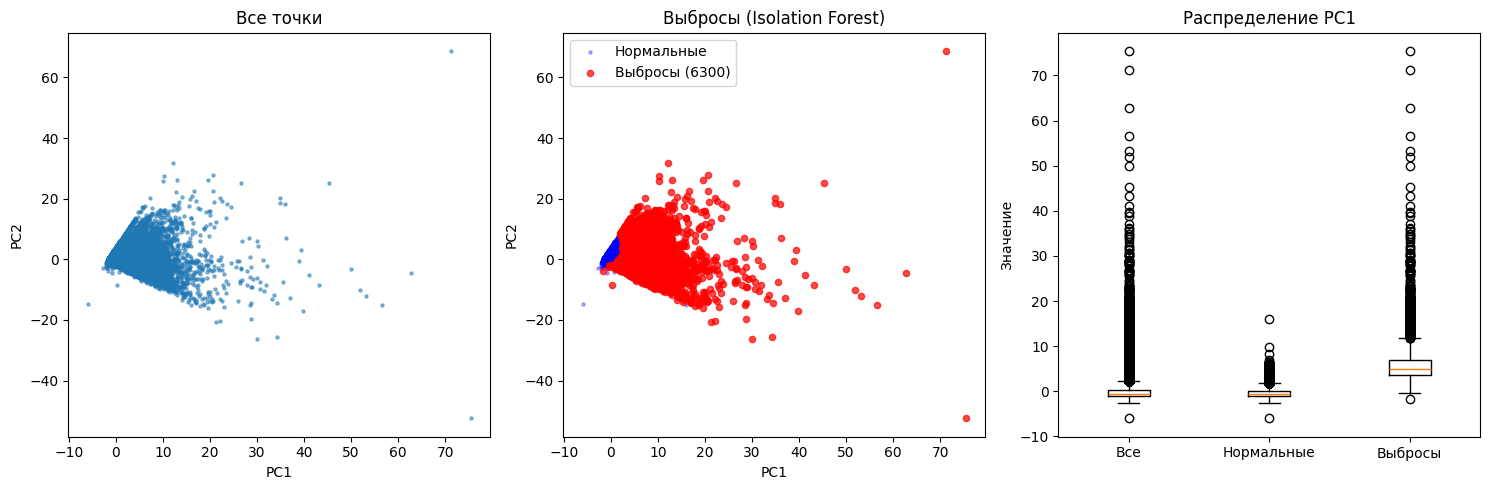

Найдено выбросов: 6300 (5.00%)
Размер X_clean: (119696, 24)
Удалено строк: 6300


In [101]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.ensemble import IsolationForest
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA

# Ваша визуализация с выбросами
plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
plt.scatter(X_pca[:, 0], X_pca[:, 1], alpha=0.5, s=5)
plt.title('Все точки')
plt.xlabel('PC1')
plt.ylabel('PC2')

# Isolation Forest для поиска выбросов
iso_forest = IsolationForest(contamination=0.05, random_state=42)  # 5% выбросов
outliers = iso_forest.fit_predict(X_scaled)
outlier_mask = outliers == -1


# 2. УДАЛЯЕМ выбросы из df_clients
df_clients_clean = df_clients[~outlier_mask].copy()
X_clean = X_scaled[~outlier_mask]

plt.subplot(1, 3, 2)
plt.scatter(X_pca[~outlier_mask, 0], X_pca[~outlier_mask, 1], 
            c='blue', alpha=0.3, s=5, label='Нормальные')
plt.scatter(X_pca[outlier_mask, 0], X_pca[outlier_mask, 1], 
            c='red', alpha=0.7, s=20, label=f'Выбросы ({outlier_mask.sum()})')
plt.title('Выбросы (Isolation Forest)')
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.legend()

plt.subplot(1, 3, 3)
# Статистика по первой компоненте
plt.boxplot([X_pca[:, 0], X_pca[~outlier_mask, 0], X_pca[outlier_mask, 0]], 
            labels=['Все', 'Нормальные', 'Выбросы'])
plt.title('Распределение PC1')
plt.ylabel('Значение')

plt.tight_layout()
plt.show()

print(f"Найдено выбросов: {outlier_mask.sum()} ({outlier_mask.sum()/len(X_scaled)*100:.2f}%)")

# После того как определили outlier_mask
X_clean = X_scaled[~outlier_mask]  # данные без выбросов
y_clean = df_clients.iloc[~outlier_mask]  # если нужен DataFrame клиентов

print(f"Размер X_clean: {X_clean.shape}")
print(f"Удалено строк: {outlier_mask.sum()}")

In [ ]:
df_clients_clean.shape[0]

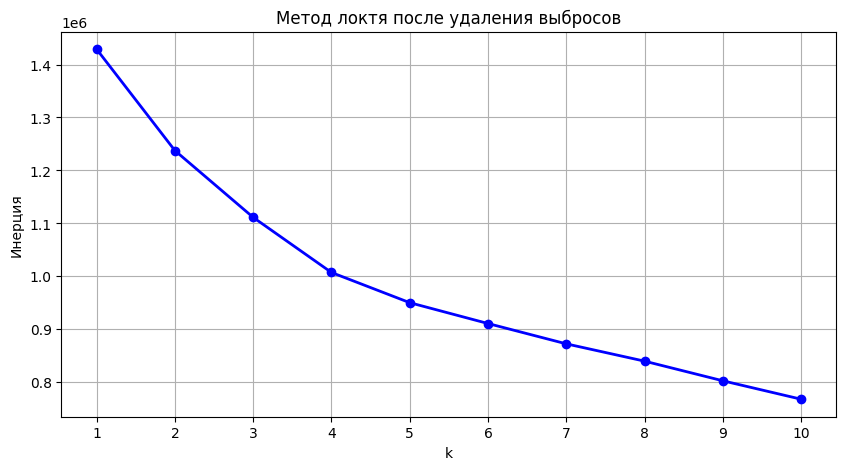

Улучшение при увеличении k:
k=2: 13.4%
k=3: 10.2%
k=4: 9.4%
k=5: 5.7%
k=6: 4.1%
k=7: 4.2%
k=8: 3.8%
k=9: 4.4%
k=10: 4.3%


In [69]:
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans

# X_clean - ваши данные после удаления выбросов
inertia = []
K = range(1, 11)

for k in K:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_clean)
    inertia.append(kmeans.inertia_)

# Визуализация
plt.figure(figsize=(10, 5))
plt.plot(K, inertia, 'bo-', linewidth=2)
plt.xlabel('k')
plt.ylabel('Инерция')
plt.title('Метод локтя после удаления выбросов')
plt.grid(True)
plt.xticks(K)
plt.show()

# Процент улучшения
print("Улучшение при увеличении k:")
for i in range(1, len(inertia)):
    improv = (inertia[i-1] - inertia[i]) / inertia[i-1] * 100
    print(f"k={i+1}: {improv:.1f}%")

In [166]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

K = range(2, 11)
silhouette_scores = []

print("Silhouette Score (на чистых данных):")
for k in K:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(X_clean)  # X_clean вместо X_pca
    score = silhouette_score(X_clean, labels, sample_size=10000)
    silhouette_scores.append(score)
    #print(f"k={k}: {score:.4f}")

optimal_k = K[np.argmax(silhouette_scores)]
print(f"\n Оптимальное k = {optimal_k}")

plt.plot(K, silhouette_scores, 'bo-')
plt.axvline(x=optimal_k, color='r', ls='--')
plt.xlabel('k')
plt.ylabel('Silhouette Score')
plt.title('Метод силуэта (после удаления выбросов)')
plt.grid(True)
plt.show()

Silhouette Score (на чистых данных):


MemoryError: Unable to allocate 763. MiB for an array with shape (10000, 10000) and data type float64

Davies-Bouldin Index (меньше = лучше):

 Оптимальное k = 4


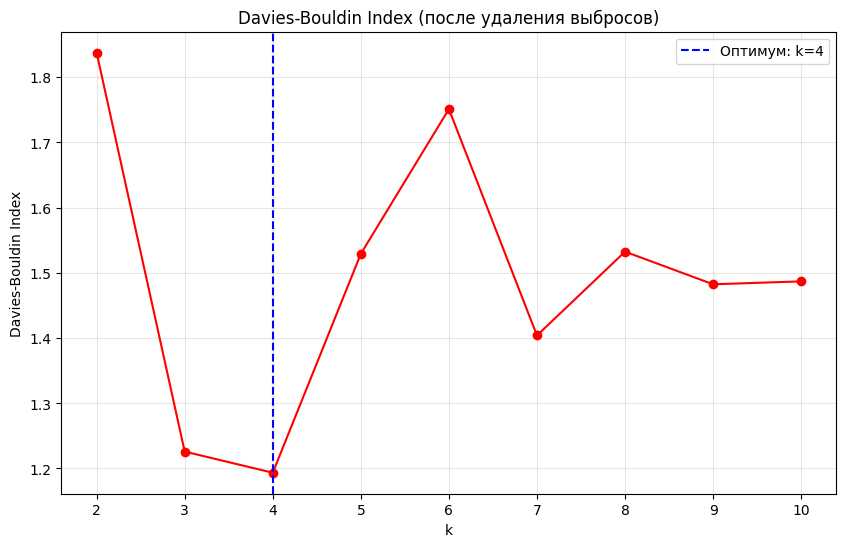

In [71]:
from sklearn.metrics import davies_bouldin_score
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
import numpy as np

results_db = {}
K = range(2, 11)

print("Davies-Bouldin Index (меньше = лучше):")
for k in K:
    kmeans = KMeans(n_clusters=k, max_iter=500, n_init=20, random_state=7)
    labels = kmeans.fit_predict(X_clean)  # X_clean вместо X_pca
    db_index = davies_bouldin_score(X_clean, labels)
    results_db[k] = db_index
    #print(f"k={k}: {db_index:.4f}")

optimal_k = min(results_db, key=results_db.get)
print(f"\n Оптимальное k = {optimal_k}")

plt.figure(figsize=(10, 6))
plt.plot(list(results_db.keys()), list(results_db.values()), 'ro-')
plt.axvline(x=optimal_k, color='b', linestyle='--', label=f'Оптимум: k={optimal_k}')
plt.xticks(np.arange(2, 11, step=1))
plt.xlabel('k')
plt.ylabel('Davies-Bouldin Index')
plt.title('Davies-Bouldin Index (после удаления выбросов)')
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

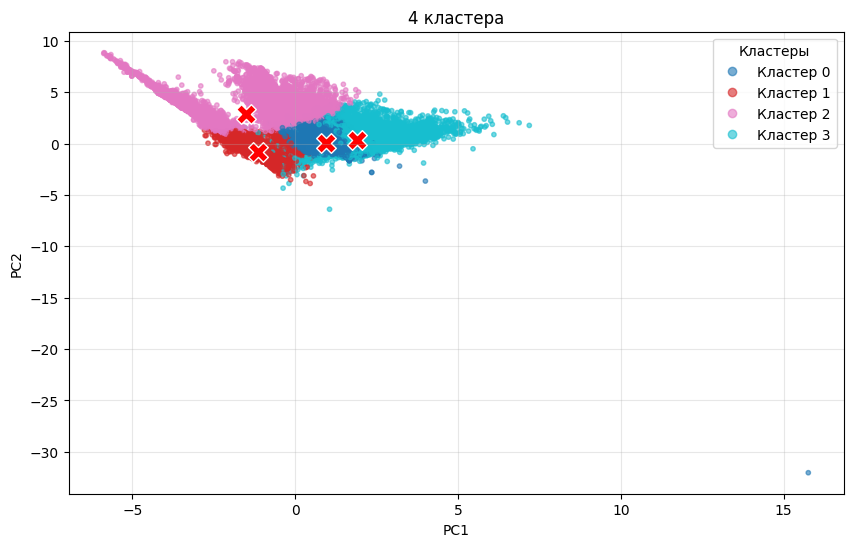

In [106]:
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import numpy as np

# Кластеризация
kmeans = KMeans(n_clusters=4, random_state=42)
labels = kmeans.fit_predict(X_clean)

# PCA для визуализации
X_pca = PCA(n_components=2).fit_transform(X_clean)

# Центры кластеров
centers = np.array([X_pca[labels == i].mean(axis=0) for i in range(4)])

# Визуализация
plt.figure(figsize=(10, 6))
scatter = plt.scatter(X_pca[:, 0], X_pca[:, 1], c=labels, cmap='tab10', alpha=0.6, s=10)
plt.scatter(centers[:, 0], centers[:, 1], c='red', s=200, marker='X', edgecolors='white')

plt.xlabel('PC1')
plt.ylabel('PC2')
plt.title('4 кластера')
plt.grid(True, alpha=0.3)

# Легенда
handles, _ = scatter.legend_elements()
plt.legend(handles, [f'Кластер {i}' for i in range(4)], title="Кластеры")

plt.show()

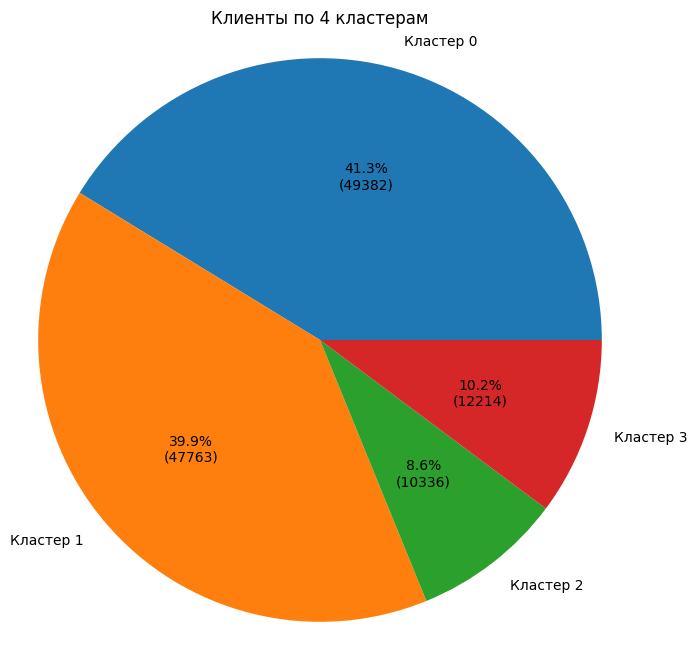

In [109]:
plt.figure(figsize=(8, 8))

cluster_counts = np.bincount(labels)

plt.pie(cluster_counts, 
        labels=[f'Кластер {i}' for i in range(4)],
        autopct=lambda pct: f'{pct:.1f}%\n({int(pct/100*sum(cluster_counts))})')
plt.title(f'Клиенты по {4} кластерам')
plt.axis('equal')
plt.show()